# Práctica Deep Learning 2025/26
## Predicción de series temporales: temperatura con Weather Dataset

**Alumno:** Santiago Mosca  
**Dataset:** Weather Long-term Time Series Forecasting  
**Objetivo:** Predecir el valor de temperatura (T) en el siguiente paso temporal (h=1) a partir de una ventana de observaciones pasadas, comparando un baseline MLP con propuestas basadas en RNN/LSTM/Atención.

# 0. Importar librerías

In [31]:
# Librerías estándar
import os
import random
import warnings
from collections import defaultdict, Counter

# Suprimir mensajes de warnings no deseados
warnings.filterwarnings('ignore', category=UserWarning, module='pytorch_lightning')

# Computación numérica y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, random_split

# PyTorch Lightning
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger

# Scikit-learn para preprocesado y métricas
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle

# Reproducibilidad
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

pl.seed_everything(SEED, workers=True)

def seed_worker(worker_id):
    """Fija la semilla para cada worker del DataLoader."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# Configuración de matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

Global seed set to 42


# 1. Carga y exploración del dataset

In [2]:
# EXPLORACIÓN DE ESTADÍSCA
# ========================

# Cargar el dataset
df_raw = pd.read_csv('cleaned_weather.csv')
df = df_raw.copy()  # para exploración y modificaciones

# Información básica
print("=== Dimensiones del dataset ===")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("=== Primeras 5 filas ===")
display(df.head())
# print(df.head())

print("\n=== Últimas 5 filas ===")
display(df.tail())
# print(df.tail())

print("\n=== Nombres de columnas ===")
print(df.columns.tolist())

print("\n=== Tipos de datos y valores nulos ===")
print(df.info())

print("\n=== Estadísticas descriptivas ===")
display(df.describe())
# print(df.describe())

# Verificar si hay valores nulos
print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())

# Ver si hay columna de tiempo (fecha/hora)
posibles_tiempo = ['date', 'datetime', 'timestamp', 'time', 'Date', 'DateTime', 'Timestamp', 'Time']
columnas_tiempo = [col for col in df.columns if col.lower() in [t.lower() for t in posibles_tiempo]]
print(f"\n=== Posibles columnas de tiempo encontradas: {columnas_tiempo} ===")

if columnas_tiempo:
    for col in columnas_tiempo:
        print(f"\nMuestra de {col}:")
        print(df[col].head())

=== Dimensiones del dataset ===
Filas: 52696, Columnas: 21

=== Primeras 5 filas ===


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81



=== Últimas 5 filas ===


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
52691,2020-12-31 23:20:00,978.32,2.28,277.16,-0.80,80.0,7.20,5.76,1.44,3.67,...,1234.61,0.73,1.40,180.6,0.0,0.0,0.0,0.0,0.0,13.40
52692,2020-12-31 23:30:00,978.30,2.13,277.01,-0.43,83.1,7.12,5.92,1.20,3.77,...,1235.20,0.43,0.82,174.0,0.0,0.0,0.0,0.0,0.0,13.42
52693,2020-12-31 23:40:00,978.26,1.99,276.88,-0.71,82.2,7.05,5.80,1.26,3.69,...,1235.82,0.38,0.76,248.9,0.0,0.0,0.0,0.0,0.0,13.45
52694,2020-12-31 23:50:00,978.26,2.07,276.95,-0.77,81.4,7.09,5.77,1.32,3.68,...,1235.49,0.57,1.07,196.6,0.0,0.0,0.0,0.0,0.0,13.47
52695,2021-01-01 00:00:00,978.24,2.01,276.89,-0.66,82.4,7.06,5.82,1.24,3.71,...,1235.71,0.57,1.08,221.3,0.0,0.0,0.0,0.0,0.0,13.48



=== Nombres de columnas ===
['date', 'p', 'T', 'Tpot', 'Tdew', 'rh', 'VPmax', 'VPact', 'VPdef', 'sh', 'H2OC', 'rho', 'wv', 'max. wv', 'wd', 'rain', 'raining', 'SWDR', 'PAR', 'max. PAR', 'Tlog']

=== Tipos de datos y valores nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      52696 non-null  object 
 1   p         52696 non-null  float64
 2   T         52696 non-null  float64
 3   Tpot      52696 non-null  float64
 4   Tdew      52696 non-null  float64
 5   rh        52696 non-null  float64
 6   VPmax     52696 non-null  float64
 7   VPact     52696 non-null  float64
 8   VPdef     52696 non-null  float64
 9   sh        52696 non-null  float64
 10  H2OC      52696 non-null  float64
 11  rho       52696 non-null  float64
 12  wv        52696 non-null  float64
 13  max. wv   52696 non-null  float64
 14  wd        52696 non-null  f

,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,H2OC,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
count,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000
mean,989.989233,10.818241,284.796938,5.409105,72.487133,14.487046,9.676828,4.810131,6.111159,9.782341,1210.882855,1.995935,3.632807,176.850276,0.011773,25.907469,131.331822,259.863438,308.601939,21.515206
std,9.207149,7.468671,7.616995,5.956722,19.230260,7.632960,4.023504,5.539320,2.561536,4.082684,36.430222,43.596931,2.462467,81.194840,0.123289,111.503420,215.735116,422.786515,569.956762,7.790620
min,955.580000,-6.440000,266.190000,-13.810000,21.160000,3.770000,2.090000,0.000000,1.300000,2.090000,1107.380000,-9999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9999.000000,6.900000
25%,984.800000,4.590000,278.550000,0.777500,58.820000,8.480000,6.460000,1.170000,4.070000,6.530000,1183.900000,1.000000,1.770000,141.100000,0.000000,0.000000,0.000000,0.000000,0.000000,15.240000
50%,990.920000,10.230000,284.320000,5.260000,75.400000,12.480000,8.890000,2.740000,5.610000,8.990000,1210.800000,1.770000,3.000000,195.500000,0.000000,0.000000,2.820000,9.670000,13.120000,20.440000
75%,995.930000,16.180000,290.260000,9.700000,87.900000,18.420000,12.050000,6.440000,7.620000,12.200000,1236.550000,2.920000,4.850000,226.700000,0.000000,0.000000,182.900000,366.437500,434.260000,26.822500
max,1020.070000,34.800000,309.130000,20.500000,100.000000,55.670000,24.160000,42.100000,15.400000,24.530000,1318.520000,13.770000,22.900000,360.000000,11.200000,600.000000,1115.290000,2131.760000,2498.940000,49.090000



=== Valores nulos por columna ===
date        0
p           0
T           0
Tpot        0
Tdew        0
rh          0
VPmax       0
VPact       0
VPdef       0
sh          0
H2OC        0
rho         0
wv          0
max. wv     0
wd          0
rain        0
raining     0
SWDR        0
PAR         0
max. PAR    0
Tlog        0
dtype: int64

=== Posibles columnas de tiempo encontradas: ['date'] ===

Muestra de date:
0    2020-01-01 00:10:00
1    2020-01-01 00:20:00
2    2020-01-01 00:30:00
3    2020-01-01 00:40:00
4    2020-01-01 00:50:00
Name: date, dtype: object


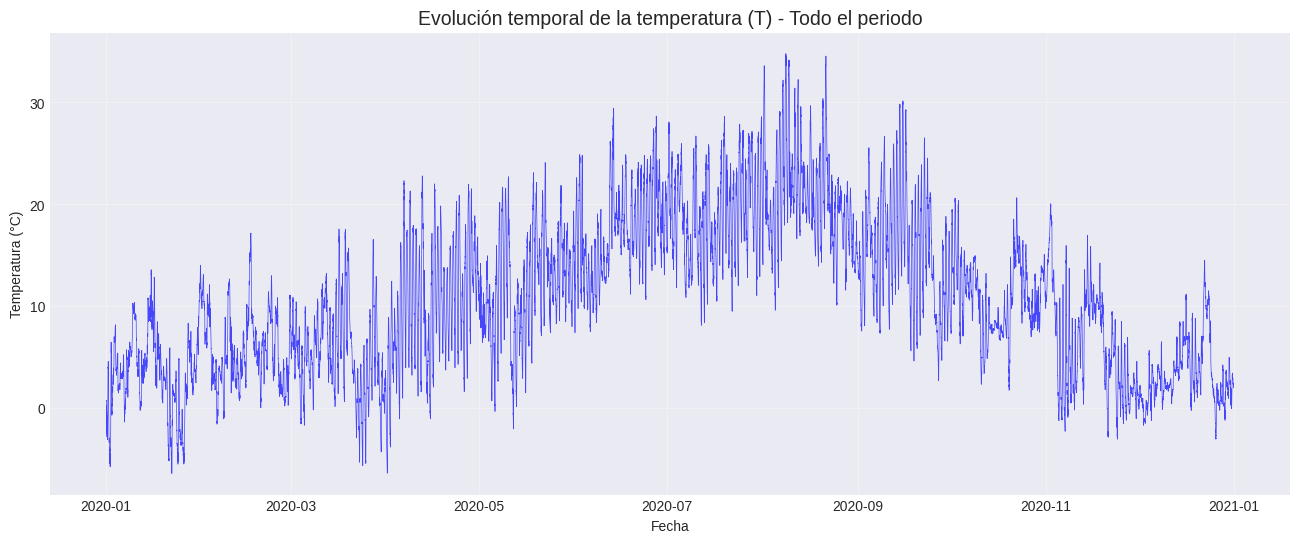

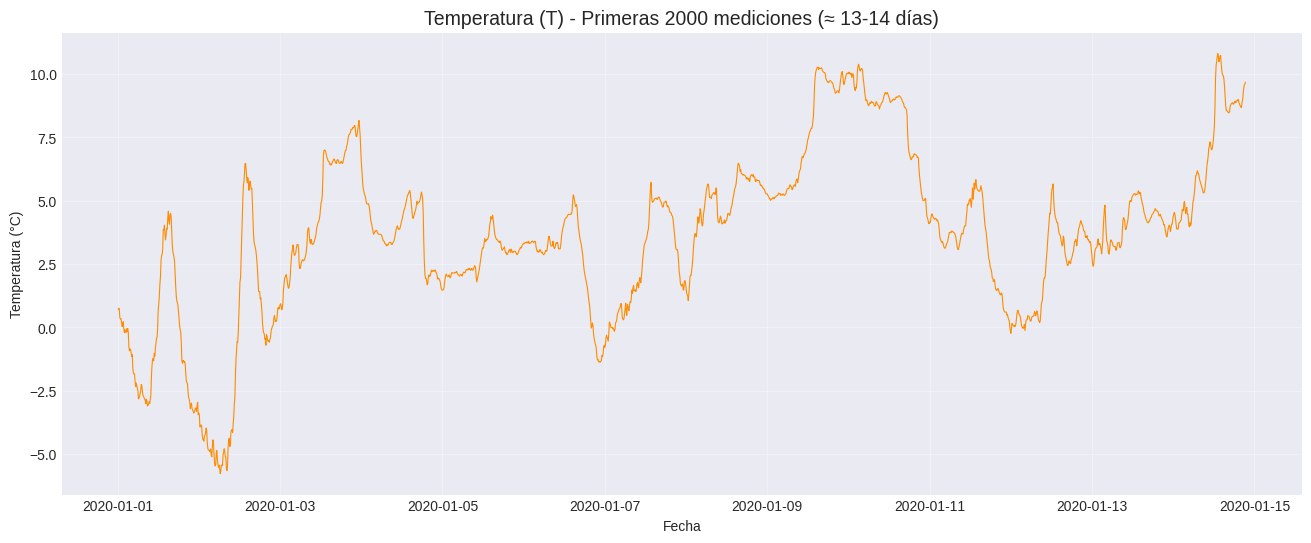

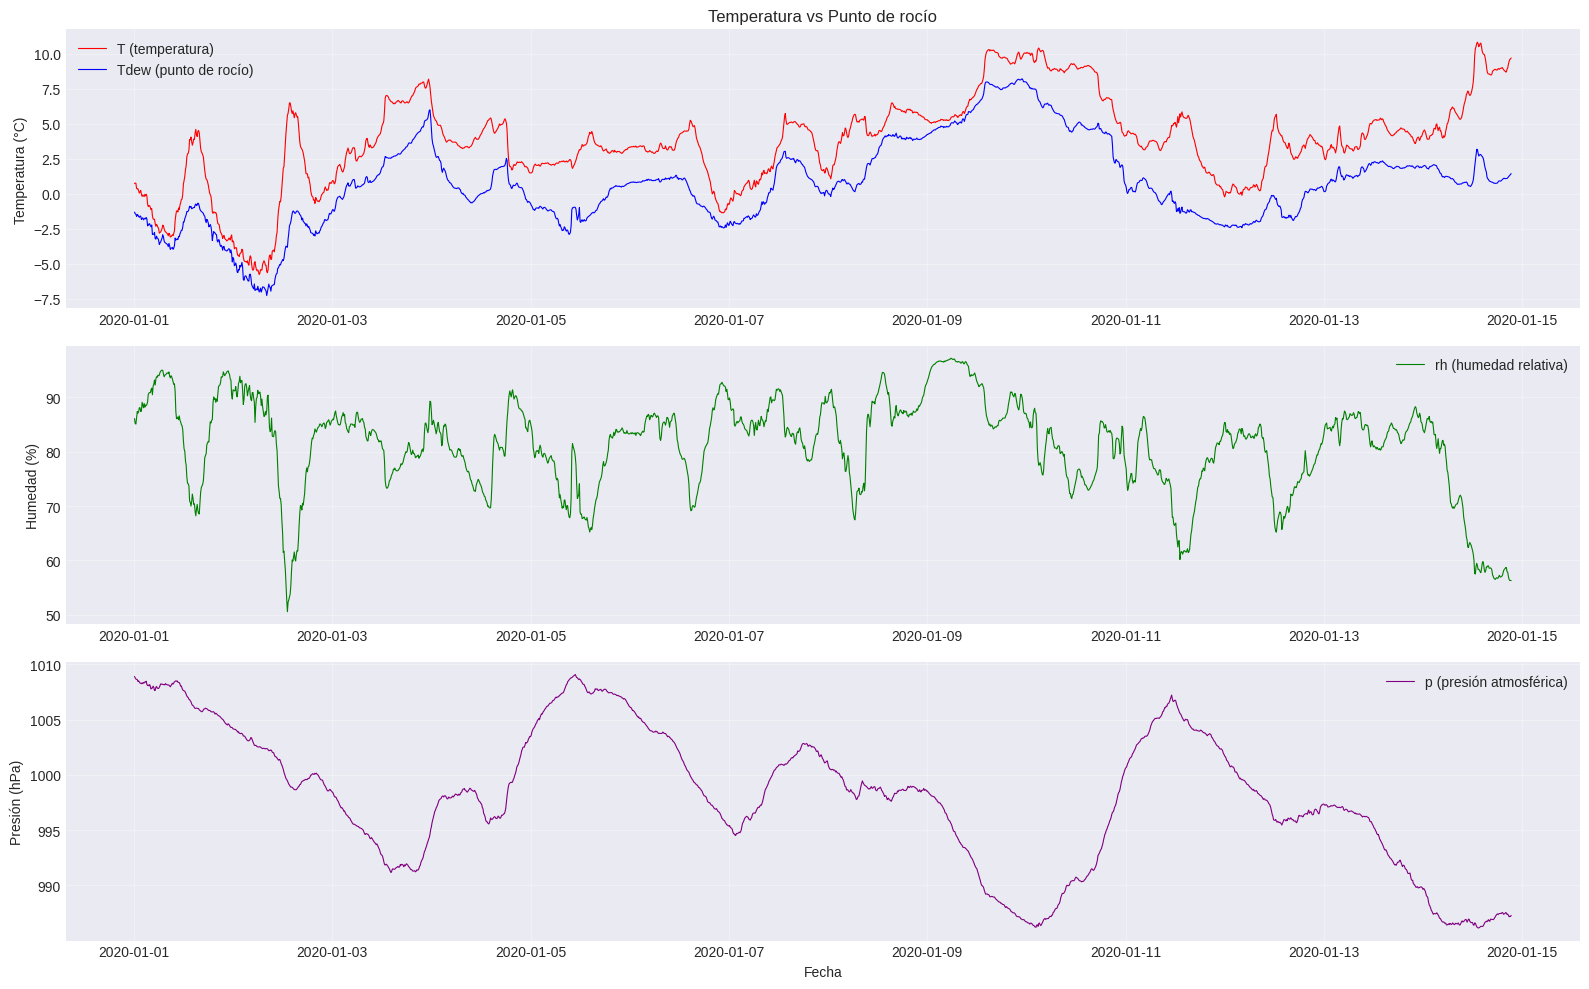

In [3]:
# EXPLORACIÓN VISUAL
# ==================

# Convertir date a datetime y establecer como índice
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Gráfico de evolución temporal de la temperatura (T)
plt.figure(figsize=(16, 6))
plt.plot(df.index, df['T'], linewidth=0.5, color='blue', alpha=0.7)
plt.title('Evolución temporal de la temperatura (T) - Todo el periodo', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Temperatura (°C)')
plt.grid(True, alpha=0.3)
plt.show()

# Primeras 2000 mediciones para ver detalle (≈ 13-14 días)
plt.figure(figsize=(16, 6))
plt.plot(df.index[:2000], df['T'][:2000], linewidth=0.8, color='darkorange')
plt.title('Temperatura (T) - Primeras 2000 mediciones (≈ 13-14 días)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Temperatura (°C)')
plt.grid(True, alpha=0.3)
plt.show()

# Comparar algunas variables atmosféricas
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

axes[0].plot(df.index[:2000], df['T'][:2000], label='T (temperatura)', color='red', linewidth=0.8)
axes[0].plot(df.index[:2000], df['Tdew'][:2000], label='Tdew (punto de rocío)', color='blue', linewidth=0.8)
axes[0].set_ylabel('Temperatura (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Temperatura vs Punto de rocío')

axes[1].plot(df.index[:2000], df['rh'][:2000], label='rh (humedad relativa)', color='green', linewidth=0.8)
axes[1].set_ylabel('Humedad (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(df.index[:2000], df['p'][:2000], label='p (presión atmosférica)', color='purple', linewidth=0.8)
axes[2].set_ylabel('Presión (hPa)')
axes[2].set_xlabel('Fecha')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Explicación de las columnas del dataset

| #  | Columna     | Descripción                              | Unidad / Notas                     |
|----|-------------|------------------------------------------|-------------------------------------|
| 1  | date        | Fecha y hora de observación              | datetime (cada 10 minutos)          |
| 2  | p           | Presión atmosférica                      | mbar                                |
| 3  | T           | Temperatura del aire                     | °C (variable objetivo)              |
| 4  | Tpot        | Temperatura potencial                     | K                                   |
| 5  | Tdew        | Temperatura de punto de rocío            | °C                                  |
| 6  | rh          | Humedad relativa                         | %                                   |
| 7  | VPmax       | Presión de vapor máxima                  | mbar                                |
| 8  | VPact       | Presión de vapor actual                  | mbar                                |
| 9  | VPdef       | Déficit de presión de vapor              | mbar (VPmax - VPact)                |
| 10 | sh          | Humedad específica                       | g/kg                                |
| 11 | H2OC        | Concentración de vapor de agua           | mmol/mol                            |
| 12 | rho         | Densidad del aire                        | g/m³                                |
| 13 | wv          | Velocidad del viento                     | m/s (contiene -9999 como error)     |
| 14 | max. wv     | Velocidad máxima del viento              | m/s                                 |
| 15 | wd          | Dirección del viento                     | grados (0-360)                      |
| 16 | rain        | Precipitación total                      | mm                                  |
| 17 | raining     | Duración de la lluvia                    | s (valor alto, posible acumulado)   |
| 18 | SWDR        | Radiación de onda corta descendente      | W/m²                                |
| 19 | PAR         | Radiación fotosintéticamente activa      | µmol/m²/s                           |
| 20 | max. PAR    | PAR máximo                               | µmol/m²/s (contiene -9999 como error) |
| 21 | Tlog        | Temperatura registrada (log)             | °C                                  |

# 2. Funciones auxiliares

In [4]:
# DataLoaders con reproducibilidad
def get_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=8, num_workers=4):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        worker_init_fn=seed_worker,
        generator=g,
        pin_memory=True,
        persistent_workers=(num_workers > 0)
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        worker_init_fn=seed_worker,
        generator=g,
        pin_memory=True,
        persistent_workers=(num_workers > 0)
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        worker_init_fn=seed_worker,
        generator=g,
        pin_memory=True,
        persistent_workers=(num_workers > 0)
    )
    return train_loader, val_loader, test_loader


def plot_losses(log_dir, version=0):
    """
    Grafica las curvas de pérdida desde los logs CSV de PyTorch Lightning.
    
    Args:
        log_dir: ruta al directorio de logs (ej. 'logs/lr_0.0001')
        version: número de versión a cargar (default 0)
    """
    import pandas as pd
    
    metrics_path = f'{log_dir}/version_{version}/metrics.csv'
    df = pd.read_csv(metrics_path)
    
    # Conservar solo filas con valores
    df_train = df[['epoch', 'train_loss']].dropna()
    df_val = df[['epoch', 'val_loss']].dropna()
    
    # Agrupar por época (promedio si hay múltiples pasos)
    train_loss = df_train.groupby('epoch')['train_loss'].mean()
    val_loss = df_val.groupby('epoch')['val_loss'].mean()
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss.index, train_loss.values, label='Train Loss', linewidth=2)
    plt.plot(val_loss.index, val_loss.values, label='Val Loss', linewidth=2)
    plt.xlabel('Época')
    plt.ylabel('MSE Loss')
    plt.title(f'Curvas de entrenamiento - {log_dir.split("/")[-1]}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Mostrar mejor val_loss
    best_val = val_loss.min()
    best_epoch = val_loss.idxmin()
    print(f"Mejor val_loss: {best_val:.6f} en época {best_epoch}")


def load_model_from_checkpoint(checkpoint_path, model_class, map_location='cpu'):
    """
    Carga un modelo de PyTorch Lightning desde un checkpoint.
    
    Args:
        checkpoint_path: ruta al archivo .ckpt
        model_class: clase del modelo (ej. MLPBaseline, LSTMForecaster)
        map_location: dispositivo donde cargar los pesos ('cpu' o 'cuda')
    """
    model = model_class.load_from_checkpoint(checkpoint_path, map_location=map_location)
    model.eval()
    return model
    

def evaluate_test_predictions(model, test_loader, scaler_y, device='cpu'):
    """
    Evalúa el modelo en test y devuelve métricas MAE y RMSE en escala original.
    
    Args:
        model: modelo entrenado
        test_loader: DataLoader de test
        scaler_y: StandardScaler usado para la variable objetivo
        device: 'cpu' o 'cuda'
    """
    model.to(device)
    model.eval()
    
    y_preds = []
    y_trues = []
    
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y_hat = model(x)
            y_preds.append(y_hat.cpu().numpy())
            y_trues.append(y.cpu().numpy())
    
    y_pred = np.concatenate(y_preds)
    y_true = np.concatenate(y_trues)
    
    # Desescalar
    y_pred_orig = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true_orig = scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
    
    # Métricas
    mae = np.mean(np.abs(y_true_orig - y_pred_orig))
    rmse = np.sqrt(np.mean((y_true_orig - y_pred_orig)**2))
    
    print(f"MAE: {mae:.4f} °C")
    print(f"RMSE: {rmse:.4f} °C")
    
    return mae, rmse, y_true_orig, y_pred_orig


def plot_predictions_vs_actual(y_true, y_pred, title="Predicción vs Real", save_path=None):
    """
    Grafica las primeras N predicciones superpuestas con valores reales.
    """
    n_samples = min(500, len(y_true))
    
    plt.figure(figsize=(14, 6))
    plt.plot(range(n_samples), y_true[:n_samples], label='Real', linewidth=1.5, alpha=0.7)
    plt.plot(range(n_samples), y_pred[:n_samples], label='Predicho', linewidth=1.5, alpha=0.7)
    plt.xlabel('Muestra (orden temporal)')
    plt.ylabel('Temperatura (°C)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

# 3. Baseline: Perceptrón Multicapa (MLP)

Siguiendo las especificaciones de la práctica, se implementa un baseline basado en un Perceptrón Multicapa con una única capa oculta de 100 neuronas. Este modelo servirá como punto de comparación frente a propuestas más avanzadas (RNN/LSTM/Atención).

## Configuración del baseline

- **Arquitectura:** MLP con una capa oculta de 100 neuronas. Función de activación ReLU en la capa oculta y salida lineal (regresión).
- **Optimizador:** SGD con momentum por defecto (0.9).
- **Learning rate:** Se probarán los valores {0.1, 0.01, 0.001, 0.0001} sobre el conjunto de validación, seleccionando el que minimice el error.
- **Batch size:** 8.
- **Early stopping:** Detención si el error de validación no mejora durante 5 epochs consecutivas.
- **Checkpointing:** Se guarda el modelo con menor error de validación.
- **Ventana temporal:** w=4, horizonte h=1 (4 mediciones pasadas para predecir el siguiente paso).
- **Preprocesado:** Normalización de las variables de entrada (StandardScaler). Se respeta el orden temporal en la partición de datos.

## Partición de los datos

Para garantizar una comparación justa con los modelos propuestos posteriormente, se fija una partición temporal única:

- **Entrenamiento (train):** 70% de los datos (primeros 36,887 registros)
- **Validación (val):** 15% de los datos (siguientes 7,904 registros)
- **Test:** 15% de los datos (últimos 7,905 registros)

El conjunto de test se mantiene intacto para todas las evaluaciones finales.

## 3.1 Preprocesado

In [5]:
# =================================================
# Preprocesado y preparación de datos para baseline
# =================================================

# 'date' ya está como datetime e índice en 'df' desde la exploración visual
# df['date'] = pd.to_datetime(df['date'])
# df.set_index('date', inplace=True)

# Asegurarnos que el índice está ordenado temporalmente
df_sorted = df.sort_index()

# -------------------------------------------------
# Tratamiento de valores erróneos (-9999)
# -------------------------------------------------
# Columnas con -9999 documentados en el dataset (códigos de error del sensor)
# Se reemplazan por NaN y luego se interpola linealmente (apropiado para series temporales)

ERROR_VALUE = -9999

# Detectar cuántos hay antes de limpiar
n_errors = (df_sorted == ERROR_VALUE).sum()
cols_with_errors = n_errors[n_errors > 0]
print("=== Valores -9999 encontrados por columna ===")
print(cols_with_errors if len(cols_with_errors) > 0 else "Ninguno")

# Reemplazar -9999 por NaN en todas las columnas numéricas
df_sorted = df_sorted.replace(ERROR_VALUE, np.nan)

# Interpolación lineal temporal (usa el índice datetime como referencia)
df_sorted = df_sorted.interpolate(method='time')

# Por si quedan NaNs al inicio/final de la serie (donde no hay vecinos para interpolar)
df_sorted = df_sorted.ffill().bfill()

# Verificar que no queden NaNs
remaining_nans = df_sorted.isnull().sum().sum()
print(f"\nNaNs restantes tras interpolación: {remaining_nans}")

# -------------------------------------------------
# Definir variables predictoras y objetivo
# -------------------------------------------------
feature_cols = df_sorted.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in feature_cols if col != 'T']
target_col = 'T'

print(f"\nVariables predictoras ({len(feature_cols)}): {feature_cols}")
print(f"Variable objetivo: {target_col}")

# Función para crear secuencias (ventanas temporales)
def create_sequences(data, target, window_size, horizon):
    """
    Crea secuencias X, y para predicción de series temporales.
    
    Args:
        data: array de features (n_samples, n_features)
        target: array del objetivo (n_samples,)
        window_size: w (pasados)
        horizon: h (futuro)
    
    Returns:
        X: (n_sequences, window_size, n_features)
        y: (n_sequences,)
    """
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size, :])
        y.append(target[i+window_size+horizon-1])
    return np.array(X), np.array(y)

# Parámetros baseline
WINDOW_SIZE = 4
HORIZON = 1

# Dividir en train/val/test respetando orden temporal
n_total = len(df_sorted)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_end = int(n_total * train_ratio)
val_end = train_end + int(n_total * val_ratio)

df_train = df_sorted.iloc[:train_end]
df_val   = df_sorted.iloc[train_end:val_end]
df_test  = df_sorted.iloc[val_end:]

print(f"\nTrain: {len(df_train)} registros")
print(f"Val:   {len(df_val)} registros")
print(f"Test:  {len(df_test)} registros")

# Normalización — scaler ajustado SOLO con train
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_raw = df_train[feature_cols].values
y_train_raw = df_train[target_col].values.reshape(-1, 1)

X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw).flatten()

X_val_scaled  = scaler_X.transform(df_val[feature_cols].values)
y_val_scaled  = scaler_y.transform(df_val[target_col].values.reshape(-1, 1)).flatten()

X_test_scaled = scaler_X.transform(df_test[feature_cols].values)
y_test_scaled = scaler_y.transform(df_test[target_col].values.reshape(-1, 1)).flatten()

# Crear secuencias
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE, HORIZON)
X_val_seq,   y_val_seq   = create_sequences(X_val_scaled,   y_val_scaled,   WINDOW_SIZE, HORIZON)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test_scaled,  WINDOW_SIZE, HORIZON)

print(f"\nForma de secuencias:")
print(f"Train X: {X_train_seq.shape}, y: {y_train_seq.shape}")
print(f"Val X:   {X_val_seq.shape},   y: {y_val_seq.shape}")
print(f"Test X:  {X_test_seq.shape},  y: {y_test_seq.shape}")

# Verificación final
print("\n=== Verificación de datos ===")
print(f"X_train_seq NaNs: {np.isnan(X_train_seq).any()} | Infs: {np.isinf(X_train_seq).any()}")
print(f"X_train_seq min/max: {X_train_seq.min():.4f} / {X_train_seq.max():.4f}")
print(f"y_train_seq NaNs: {np.isnan(y_train_seq).any()} | Infs: {np.isinf(y_train_seq).any()}")

=== Valores -9999 encontrados por columna ===
wv           1
max. PAR    30
dtype: int64

NaNs restantes tras interpolación: 0

Variables predictoras (19): ['p', 'Tpot', 'Tdew', 'rh', 'VPmax', 'VPact', 'VPdef', 'sh', 'H2OC', 'rho', 'wv', 'max. wv', 'wd', 'rain', 'raining', 'SWDR', 'PAR', 'max. PAR', 'Tlog']
Variable objetivo: T

Train: 36887 registros
Val:   7904 registros
Test:  7905 registros

Forma de secuencias:
Train X: (36883, 4, 19), y: (36883,)
Val X:   (7900, 4, 19),   y: (7900,)
Test X:  (7901, 4, 19),  y: (7901,)

=== Verificación de datos ===
X_train_seq NaNs: False | Infs: False
X_train_seq min/max: -3.3094 / 91.1234
y_train_seq NaNs: False | Infs: False


In [6]:
# Identificar qué columna tiene el valor extremo post-normalización
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
max_per_col = X_train_df.abs().max().sort_values(ascending=False)
print("=== Máximo valor absoluto normalizado por columna ===")
print(max_per_col.head(10))

# Ver el valor crudo en esa columna
worst_col = max_per_col.index[0]
print(f"\nColumna problemática: {worst_col}")
print(f"Estadísticas crudas en train:")
print(df_train[worst_col].describe())
print(f"\nValores extremos (top 5):")
print(df_train[worst_col].nlargest(5))
print(df_train[worst_col].nsmallest(5))

=== Máximo valor absoluto normalizado por columna ===
rain        91.123372
max. wv      7.372591
wv           6.928763
VPdef        6.143034
raining      5.474397
VPmax        4.931024
SWDR         3.998061
PAR          3.875009
max. PAR     3.681566
p            3.409631
dtype: float64

Columna problemática: rain
Estadísticas crudas en train:
count    36887.000000
mean         0.011481
std          0.122786
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         11.200000
Name: rain, dtype: float64

Valores extremos (top 5):
date
2020-06-16 17:10:00    11.2
2020-06-03 14:40:00     5.1
2020-08-12 17:00:00     4.7
2020-06-03 14:20:00     4.1
2020-08-02 15:20:00     4.1
Name: rain, dtype: float64
date
2020-01-01 00:10:00    0.0
2020-01-01 00:20:00    0.0
2020-01-01 00:30:00    0.0
2020-01-01 00:40:00    0.0
2020-01-01 00:50:00    0.0
Name: rain, dtype: float64


## 3.2 Preprocesado v2 — Clipping de variable `rain` (y `raining`)

Durante la verificación post-normalización se detectó que la columna `rain` presenta un valor
máximo normalizado de ~91σ, a pesar de no contener errores de sensor. El problema es estructural:
`rain` es una variable extremadamente esparsa (más del 75% de los valores son exactamente 0),
lo que produce una media y desvío estándar muy pequeños. Cualquier evento de lluvia real queda
amplificado desproporcionadamente tras el StandardScaler.

Lo mismo ocurre con `raining` (duración de lluvia), que comparte la misma naturaleza esparsa.

**Decisión metodológica:** se aplica clipping al percentil 99 sobre la serie completa
(antes del split) para ambas columnas. Esto no elimina la información cualitativa del evento
(sigue reflejando que llovió y cuánto), sino que limita el impacto cuantitativo de eventos
extremos aislados sobre la normalización. El criterio percentil 99 es conservador: solo afecta
al 1% superior de observaciones.

El clipping se calcula sobre `df_sorted` completo antes de la partición temporal, garantizando
que el umbral sea representativo del dataset global y se aplique de forma consistente a train,
val y test. El orden temporal de los datos se preserva íntegramente.

**Resultado:** `rain` se reduce de ~91σ a ~7.8σ tras el clipping. Este valor persiste porque
el percentil 99 de `rain` cae en 0.3 mm, lo que refleja que la distribución es intrínsecamente
esparsa (99% de observaciones con valor 0 o cercano a 0). Eliminar la columna implicaría una
intervención mayor que la contemplada bajo el criterio de preprocesado mínimo, por lo que se
opta por conservarla y asumir este residuo como una limitación conocida del preprocesado.

In [7]:
# =================================================
# Preprocesado v2 — Clipping de rain y raining
# =================================================

# Columnas con distribución esparsa que generan outliers post-normalización
cols_to_clip = ['rain', 'raining']

# Calcular umbral sobre la serie completa (antes del split)
clip_upper = {}
for col in cols_to_clip:
    upper = df_sorted[col].quantile(0.99)
    clip_upper[col] = upper
    print(f"{col}: percentil 99 = {upper:.4f}, max original = {df_sorted[col].max():.4f}")

# Aplicar clipping
df_sorted = df_sorted.copy()
for col in cols_to_clip:
    df_sorted[col] = df_sorted[col].clip(upper=clip_upper[col])

print("\n=== Post-clipping ===")
for col in cols_to_clip:
    print(f"{col}: max tras clipping = {df_sorted[col].max():.4f}")

# --- Re-ejecutar el preprocesado completo desde df_sorted ---

feature_cols = df_sorted.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in feature_cols if col != 'T']
target_col = 'T'

n_total   = len(df_sorted)
train_end = int(n_total * 0.7)
val_end   = train_end + int(n_total * 0.15)

df_train = df_sorted.iloc[:train_end]
df_val   = df_sorted.iloc[train_end:val_end]
df_test  = df_sorted.iloc[val_end:]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(df_train[feature_cols].values)
y_train_scaled = scaler_y.fit_transform(df_train[target_col].values.reshape(-1, 1)).flatten()

X_val_scaled  = scaler_X.transform(df_val[feature_cols].values)
y_val_scaled  = scaler_y.transform(df_val[target_col].values.reshape(-1, 1)).flatten()

X_test_scaled = scaler_X.transform(df_test[feature_cols].values)
y_test_scaled = scaler_y.transform(df_test[target_col].values.reshape(-1, 1)).flatten()

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE, HORIZON)
X_val_seq,   y_val_seq   = create_sequences(X_val_scaled,   y_val_scaled,   WINDOW_SIZE, HORIZON)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test_scaled,  WINDOW_SIZE, HORIZON)

# Verificación final
print("\n=== Verificación post-clipping ===")
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
print("Top 5 columnas por valor absoluto máximo normalizado:")
print(X_train_df.abs().max().sort_values(ascending=False).head())
print(f"\nX_train_seq min/max: {X_train_seq.min():.4f} / {X_train_seq.max():.4f}")

rain: percentil 99 = 0.3000, max original = 11.2000
raining: percentil 99 = 600.0000, max original = 600.0000

=== Post-clipping ===
rain: max tras clipping = 0.3000
raining: max tras clipping = 600.0000

=== Verificación post-clipping ===
Top 5 columnas por valor absoluto máximo normalizado:
rain       7.787385
max. wv    7.372591
wv         6.928763
VPdef      6.143034
raining    5.474397
dtype: float64

X_train_seq min/max: -3.3094 / 7.7874


## 3.3 Definición del baseline

In [8]:
# ===============================
# Dataset y DataLoader de PyTorch
# ===============================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Crear datasets
train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)
val_dataset = TimeSeriesDataset(X_val_seq, y_val_seq)
test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

# DataLoaders con batch_size=8
BATCH_SIZE = 8

train_loader, val_loader, test_loader = get_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0  # para notebook local
)

In [9]:
# ==================================
# Definición del modelo baseline MLP
# ==================================

class MLPBaseline(pl.LightningModule):
    def __init__(self, input_dim, learning_rate=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.hidden    = nn.Linear(input_dim, 100)
        self.output    = nn.Linear(100, 1)
        self.relu      = nn.ReLU()
        self.criterion = nn.MSELoss()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.hidden(x))
        x = self.output(x)
        return x.squeeze()

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.criterion(self(x), y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = self.criterion(self(x), y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(),
                               lr=self.hparams.learning_rate,
                               momentum=0.9)

## 3.4 Entrenamiento del Baseline

En esta sección se presenta el código de instanciación y entrenamiento del modelo tal como se ejecutaría en el notebook. No obstante, el entrenamiento se llevó a cabo en una máquina remota con GPU para disponer de mayor capacidad de cómputo. Los resultados se recuperan posteriormente cargando los checkpoints y evaluaciones en test generados.

### Configuración experimental

Se implementó un MLP con una capa oculta de 100 neuronas, optimizador SGD con momentum=0.9, batch size=8 y early stopping con paciencia de 5 épocas. La ventana temporal se fijó en w=4 y el horizonte de predicción en h=1, según lo especificado para el baseline.

Se probaron los siguientes learning rates: {0.1, 0.01, 0.001, 0.0001}. Para cada uno se entrenó el modelo hasta early stopping o hasta completar 100 épocas.

In [10]:
# NO EJECUTAR!

# # ================================
# # Búsqueda de learning rate óptimo
# # ================================

# learning_rates = [0.1, 0.01, 0.001, 0.0001]
# best_val_loss  = float('inf')
# best_lr        = None
# best_ckpt_path = None

# for lr in learning_rates:
#     print(f"\n--- LR={lr} ---")

#     checkpoint = ModelCheckpoint(
#         monitor='val_loss',
#         mode='min',
#         save_top_k=1,
#         filename=f'model_lr{lr}_best'
#     )
#     early_stop = EarlyStopping(monitor='val_loss', patience=5, mode='min')
#     logger     = CSVLogger(save_dir='baseline_logs', name=f'lr_{lr}')

#     trainer = pl.Trainer(
#         max_epochs=100,
#         callbacks=[checkpoint, early_stop],
#         logger=logger,
#         accelerator='gpu',
#         devices=1,
#         log_every_n_steps=50
#     )

#     model = MLPBaseline(input_dim=WINDOW_SIZE * len(feature_cols), learning_rate=lr)
#     trainer.fit(model, train_loader, val_loader)

#     val_loss = checkpoint.best_model_score.item()
#     print(f"Mejor val_loss para LR={lr}: {val_loss:.6f}")

#     if val_loss < best_val_loss:
#         best_val_loss  = val_loss
#         best_lr        = lr
#         best_ckpt_path = checkpoint.best_model_path

# print(f"\n=== Mejor LR: {best_lr} | val_loss: {best_val_loss:.6f} ===")
# print(f"Checkpoint: {best_ckpt_path}")

In [11]:
# # NO EJECUTAR!

# # ==========================================
# # Evaluación en test con el mejor checkpoint
# # ==========================================
# print("\n--- Evaluando en test ---")

# best_model = MLPBaseline.load_from_checkpoint(best_ckpt_path)
# best_model.eval()
# best_model.to('cpu')

# y_preds, y_trues = [], []
# with torch.no_grad():
#     for x, y in test_loader:
#         y_hat = best_model(x)
#         y_preds.append(y_hat.numpy())
#         y_trues.append(y.numpy())

# y_pred_scaled = np.concatenate(y_preds)
# y_true_scaled = np.concatenate(y_trues)

# y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
# y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()

# mae  = mean_absolute_error(y_true, y_pred)
# rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# print(f"MAE  : {mae:.4f} °C")
# print(f"RMSE : {rmse:.4f} °C")

# np.savez(
#     'baseline_results/baseline_test_results.npz',
#     y_true=y_true,
#     y_pred=y_pred,
#     mae=np.array(mae),
#     rmse=np.array(rmse),
#     best_lr=np.array(best_lr)
# )
# print("\nResultados guardados en baseline_results/baseline_test_results.npz")

In [12]:
# Script corrido en remoto para aprovechar potencia de cálculo de GPU
!cat train_baseline_v2.py

#!/usr/bin/env python3
# train_baseline_v2.py

import os
import random
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader

# -------------------------------------------------------
# Reproducibilidad
# -------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
pl.seed_everything(SEED, workers=True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()

### 3.4.1 Comparativa de learning rates

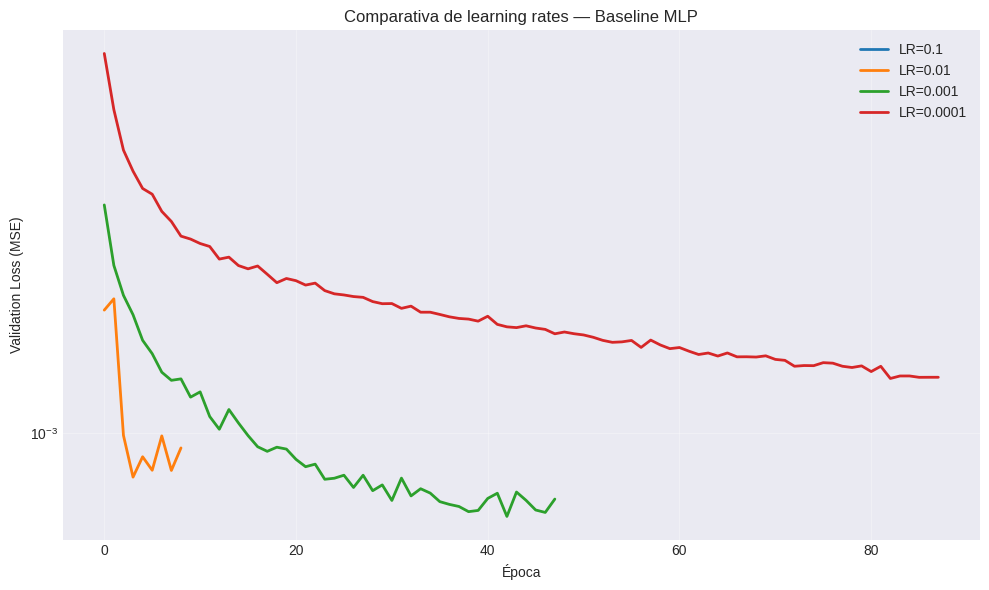

Mejor LR según logs: 0.001 (val_loss=0.000684)


In [13]:
# -------------------------------------------------------
# 3.4.1 Comparativa de learning rates
# -------------------------------------------------------

learning_rates = [0.1, 0.01, 0.001, 0.0001]
VERSION = 1

plt.figure(figsize=(10, 6))

best_lr_from_logs = None
best_val_loss_from_logs = float('inf')

for lr in learning_rates:
    metrics_path = f'baseline_logs/lr_{lr}/version_{VERSION}/metrics.csv'
    try:
        df_log = pd.read_csv(metrics_path)
        df_val = df_log[['epoch', 'val_loss']].dropna()
        val_by_epoch = df_val.groupby('epoch')['val_loss'].mean()
        plt.plot(val_by_epoch.index, val_by_epoch.values, label=f'LR={lr}', linewidth=2)

        min_val = val_by_epoch.min()
        if min_val < best_val_loss_from_logs:
            best_val_loss_from_logs = min_val
            best_lr_from_logs = lr

    except FileNotFoundError:
        print(f"Log no encontrado para LR={lr}: {metrics_path}")

plt.xlabel('Época')
plt.ylabel('Validation Loss (MSE)')
plt.title('Comparativa de learning rates — Baseline MLP')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mejor LR según logs: {best_lr_from_logs} (val_loss={best_val_loss_from_logs:.6f})")

### 3.4.2 Curvas de entrenamiento del mejor LR

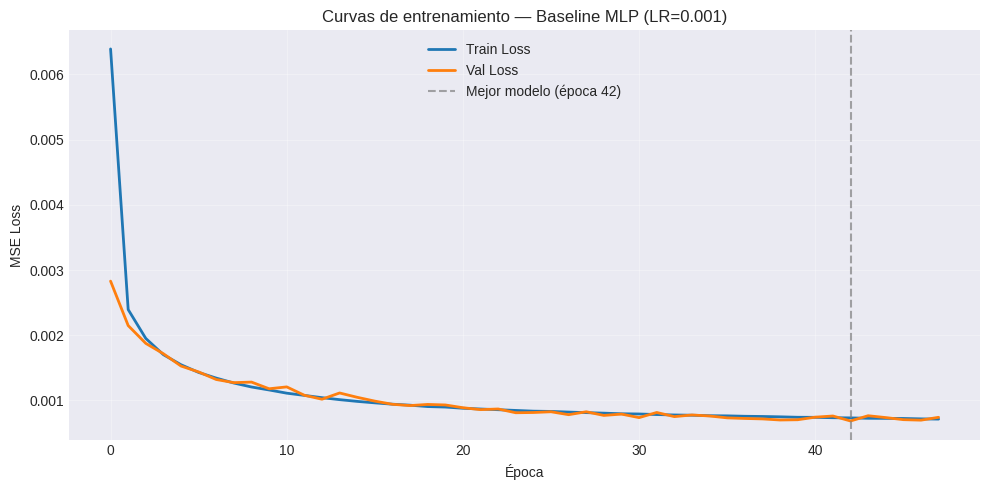

Mejor val_loss: 0.000684 en época 42
Épocas totales entrenadas: 47


In [14]:
# -------------------------------------------------------
# 3.4.2 Curvas de entrenamiento del mejor LR
# -------------------------------------------------------

metrics_path = f'baseline_logs/lr_{best_lr_from_logs}/version_{VERSION}/metrics.csv'
df_log = pd.read_csv(metrics_path)

df_train = df_log[['epoch', 'train_loss_epoch']].dropna()
df_val   = df_log[['epoch', 'val_loss']].dropna()

train_by_epoch = df_train.groupby('epoch')['train_loss_epoch'].mean()
val_by_epoch   = df_val.groupby('epoch')['val_loss'].mean()

best_epoch = val_by_epoch.idxmin()
best_val   = val_by_epoch.min()

plt.figure(figsize=(10, 5))
plt.plot(train_by_epoch.index, train_by_epoch.values, label='Train Loss', linewidth=2)
plt.plot(val_by_epoch.index,   val_by_epoch.values,   label='Val Loss',   linewidth=2)
plt.axvline(x=best_epoch, linestyle='--', color='gray', alpha=0.7, label=f'Mejor modelo (época {best_epoch})')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title(f'Curvas de entrenamiento — Baseline MLP (LR={best_lr_from_logs})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mejor val_loss: {best_val:.6f} en época {best_epoch}")
print(f"Épocas totales entrenadas: {val_by_epoch.index[-1]}")

### 3.4.3 Evaluación en test

=== Métricas del Baseline MLP en test ===
Learning rate seleccionado : 0.001
MAE                        : 0.1262 °C
RMSE                       : 0.1742 °C


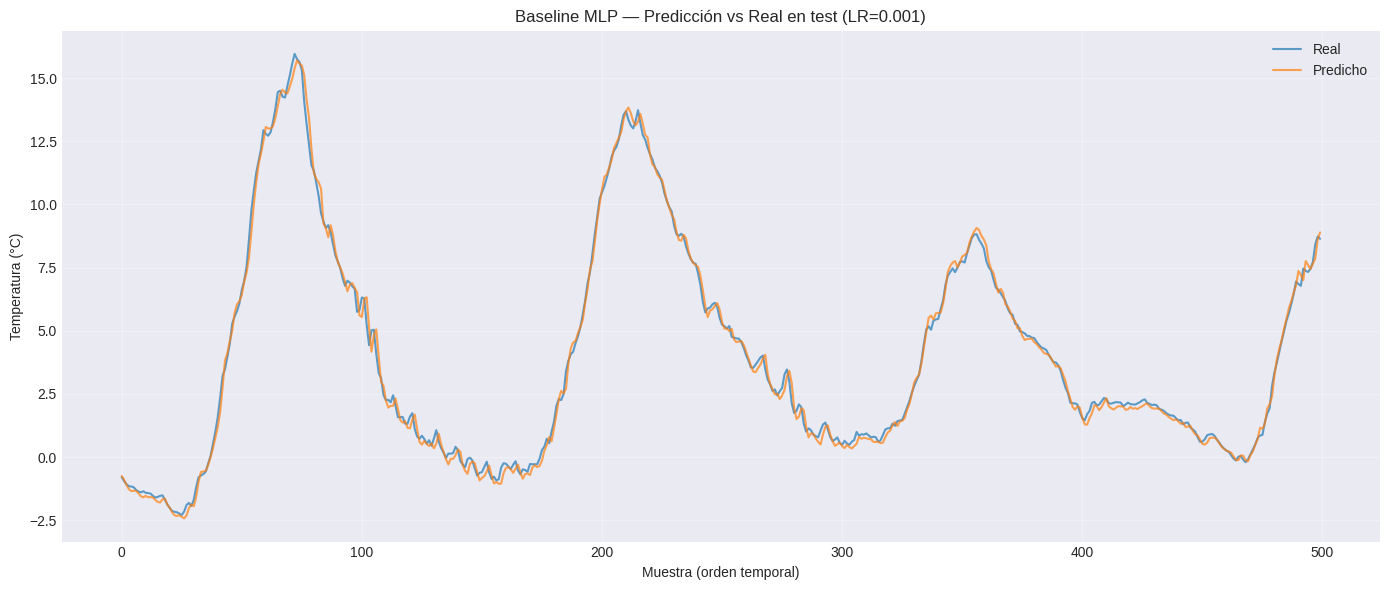

In [15]:
# -------------------------------------------------------
# 3.4.3 Evaluación en test
# -------------------------------------------------------

results = np.load('baseline_results/baseline_test_results.npz')
y_true   = results['y_true']
y_pred   = results['y_pred']
mae      = float(results['mae'])
rmse     = float(results['rmse'])
best_lr  = float(results['best_lr'])

print(f"=== Métricas del Baseline MLP en test ===")
print(f"Learning rate seleccionado : {best_lr}")
print(f"MAE                        : {mae:.4f} °C")
print(f"RMSE                       : {rmse:.4f} °C")

# Guardar para tabla comparativa final
baseline_results = {
    'modelo'          : 'MLP Baseline',
    'learning_rate'   : best_lr,
    'window_size'     : WINDOW_SIZE,
    'batch_size'      : BATCH_SIZE,
    'neuronas_ocultas': 100,
    'MAE'             : mae,
    'RMSE'            : rmse
}

plot_predictions_vs_actual(
    y_true, y_pred,
    title=f'Baseline MLP — Predicción vs Real en test (LR={best_lr})'
)

## 3.5 Análisis del Baseline

### Selección del learning rate

La búsqueda sobre el conjunto de validación arrojó los siguientes comportamientos:

- **LR=0.1:** inestabilidad inmediata. El optimizador SGD diverge desde las primeras épocas, produciendo explosión de gradientes.
- **LR=0.01:** descenso inicial rápido seguido de oscilaciones. El early stopping detiene el entrenamiento alrededor de la época 10, sin haber convergido de forma estable.
- **LR=0.001:** convergencia suave con oscilaciones moderadas en validación. El modelo alcanza su mejor val_loss (0.000684) en la época 42 y el early stopping detiene el entrenamiento en la época 47. Las curvas de train y validación evolucionan de forma paralela, sin signos de sobreajuste.
- **LR=0.0001:** descenso estable pero insuficiente. El modelo entrena hasta la época 88 aproximadamente sin alcanzar el nivel de convergencia de LR=0.001, evidenciando underfitting por una tasa de aprendizaje excesivamente conservadora.

**Learning rate seleccionado: 0.001**, por reportar el menor error de validación.

### Resultados en test

| Modelo | LR | Ventana | MAE (°C) | RMSE (°C) |
|--------|----|---------|----------|-----------|
| MLP Baseline | 0.001 | 4 | 0.1262 | 0.1742 |

### Interpretación

Los valores de MAE (0.13°C) y RMSE (0.17°C) son bajos en términos absolutos. Esto es esperable en un problema de predicción con horizonte h=1 sobre mediciones cada 10 minutos: la temperatura varía poco entre pasos consecutivos, por lo que incluso un modelo simple puede aproximarse bien al siguiente valor aprendiendo esencialmente la inercia de la serie.

Este resultado establece una referencia competitiva que los modelos propuestos deberán superar. La ausencia de sobreajuste en el baseline sugiere que la mejora vendrá de capturar dependencias temporales más ricas, algo que el MLP no puede hacer al tratar la ventana como un vector plano sin estructura secuencial.

# 4. Propuestas 1 y 2: LSTM

## 4.1 Justificación del modelo

Para el problema de predicción de temperatura en series temporales se propone una red neuronal
recurrente basada en **Long Short-Term Memory (LSTM)**. A diferencia del MLP baseline, que trata
la ventana temporal como un vector plano sin estructura secuencial, la LSTM procesa la secuencia
paso a paso manteniendo un estado oculto que actúa como memoria del contexto pasado.

### Fortalezas
- **Memoria selectiva:** los gates de entrada, olvido y salida permiten al modelo aprender qué
  información retener y qué descartar a lo largo de la secuencia, evitando el problema de
  vanishing gradient que afecta a las RNN vanilla.
- **Captura de dependencias temporales:** puede modelar patrones de inercia térmica y tendencias
  horarias que una ventana plana no puede representar.
- **Estándar en forecasting:** es el modelo de referencia en predicción de series temporales,
  con amplia validación empírica en dominios meteorológicos.

### Debilidades
- **Mayor número de parámetros** que una RNN vanilla o una GRU, lo que implica mayor tiempo
  de entrenamiento.
- **Procesamiento secuencial:** a diferencia de arquitecturas basadas en atención (Transformer),
  la LSTM no paraleliza el procesamiento de la secuencia, lo que limita su escalabilidad con
  ventanas muy largas.

Para ventanas de tamaño moderado (w=36, w=144) y horizonte h=1, estas debilidades son asumibles
y las fortalezas dominan la elección.

## 4.2 Arquitectura y justificación de hiperparámetros

Se proponen dos configuraciones para explorar el efecto del tamaño de ventana y la capacidad
del modelo:

| Hiperparámetro | Propuesta 1 | Propuesta 2 | Justificación |
|----------------|-------------|-------------|---------------|
| Ventana (w) | 36 | 144 | 36 pasos = 6h (inercia local); 144 pasos = 24h (ciclo diario completo) |
| Hidden size | 64 | 128 | Suficiente capacidad para 19 features de entrada; evita sobreparametrizar |
| Capas LSTM | 1 | 2 | 1 capa como referencia; 2 capas para capturar jerarquía temporal |
| Dropout | 0.0 | 0.2 | Sin dropout en 1 capa; regularización entre capas en la configuración más profunda |
| Batch size | 32 | 64 | Mayor que el baseline (8) para aprovechar la GPU sin sacrificar estabilidad |
| Early stopping | paciencia 10 | paciencia 10 | Más flexible que el baseline (5) dado el mayor espacio de hiperparámetros |
| Max épocas | 100 | 100 | Cota superior; el early stopping detiene antes si corresponde |

La capa de salida es en ambos casos una capa lineal de tamaño 1 (regresión), que recibe el
estado oculto del último paso temporal de la LSTM.

## 4.3 Definición del modelo LSTM

In [16]:
# ============================================
# Definición del modelo LSTM
# ============================================

class LSTMForecaster(pl.LightningModule):
    def __init__(self, input_dim, hidden_size=64, num_layers=1, dropout=0.0, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        
        self.output = nn.Linear(hidden_size, 1)
        self.criterion = nn.MSELoss()

    def forward(self, x):
        # x: (batch, window_size, input_dim)
        lstm_out, _ = self.lstm(x)
        # Tomar solo el último paso temporal
        last_hidden = lstm_out[:, -1, :]
        return self.output(last_hidden).squeeze()

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.criterion(self(x), y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = self.criterion(self(x), y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

## 4.4 Entrenamiento

Las propuestas de LSTM se corrieron en GPU remoto por las mismas razones expuestas para el baseline.

In [17]:
# NO EJECUTAR!

# # ============================================
# # Entrenamiento LSTM — Propuesta 1 y 2
# # ============================================

# lstm_configs = [
#     {
#         'nombre'       : 'LSTM_p1_w36_h64_l1',
#         'window_size'  : 36,
#         'hidden_size'  : 64,
#         'num_layers'   : 1,
#         'dropout'      : 0.0,
#         'learning_rate': 0.001,
#         'batch_size'   : 32,
#     },
#     {
#         'nombre'       : 'LSTM_p2_w144_h128_l2',
#         'window_size'  : 144,
#         'hidden_size'  : 128,
#         'num_layers'   : 2,
#         'dropout'      : 0.2,
#         'learning_rate': 0.001,
#         'batch_size'   : 64,
#     },
# ]

# for config in lstm_configs:
#     print(f"\n{'='*50}")
#     print(f"Configuración: {config['nombre']}")
#     print(f"{'='*50}")

#     # Regenerar secuencias para esta ventana
#     w = config['window_size']
#     X_tr_seq, y_tr_seq = create_sequences(X_train_scaled, y_train_scaled, w, HORIZON)
#     X_va_seq, y_va_seq = create_sequences(X_val_scaled,   y_val_scaled,   w, HORIZON)

#     print(f"Secuencias — Train: {X_tr_seq.shape} | Val: {X_va_seq.shape}")

#     # DataLoaders
#     train_loader_lstm, val_loader_lstm, _ = get_dataloaders(
#         TimeSeriesDataset(X_tr_seq, y_tr_seq),
#         TimeSeriesDataset(X_va_seq, y_va_seq),
#         TimeSeriesDataset(X_va_seq, y_va_seq),  # placeholder, no se usa aquí
#         batch_size=config['batch_size'],
#         num_workers=0
#     )

#     # Modelo
#     model = LSTMForecaster(
#         input_dim     =X_tr_seq.shape[2],
#         hidden_size   =config['hidden_size'],
#         num_layers    =config['num_layers'],
#         dropout       =config['dropout'],
#         learning_rate =config['learning_rate']
#     )

#     # Callbacks y logger
#     checkpoint = ModelCheckpoint(
#         monitor  ='val_loss',
#         mode     ='min',
#         save_top_k=1,
#         filename =f"{config['nombre']}_best"
#     )
#     early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')
#     logger     = CSVLogger(save_dir='lstm_logs', name=config['nombre'])

#     trainer = pl.Trainer(
#         max_epochs      =100,
#         callbacks       =[checkpoint, early_stop],
#         logger          =logger,
#         accelerator     ='auto',
#         devices         =1,
#         log_every_n_steps=10,
#         enable_progress_bar=True
#     )

#     trainer.fit(model, train_loader_lstm, val_loader_lstm)

#     print(f"Mejor val_loss: {checkpoint.best_model_score:.6f}")
#     print(f"Checkpoint: {checkpoint.best_model_path}")

In [18]:
# Script corrido en remoto para aprovechar potencia de cálculo de GPU
!cat train_lstm.py

#!/usr/bin/env python3
# train_lstm.py

import os
import random
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader

# -------------------------------------------------------
# Reproducibilidad
# -------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
pl.seed_everything(SEED, workers=True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manu

## 4.4 Análisis de resultados - LSTM

### 4.4.1 Comparativa val_loss entre propuestas

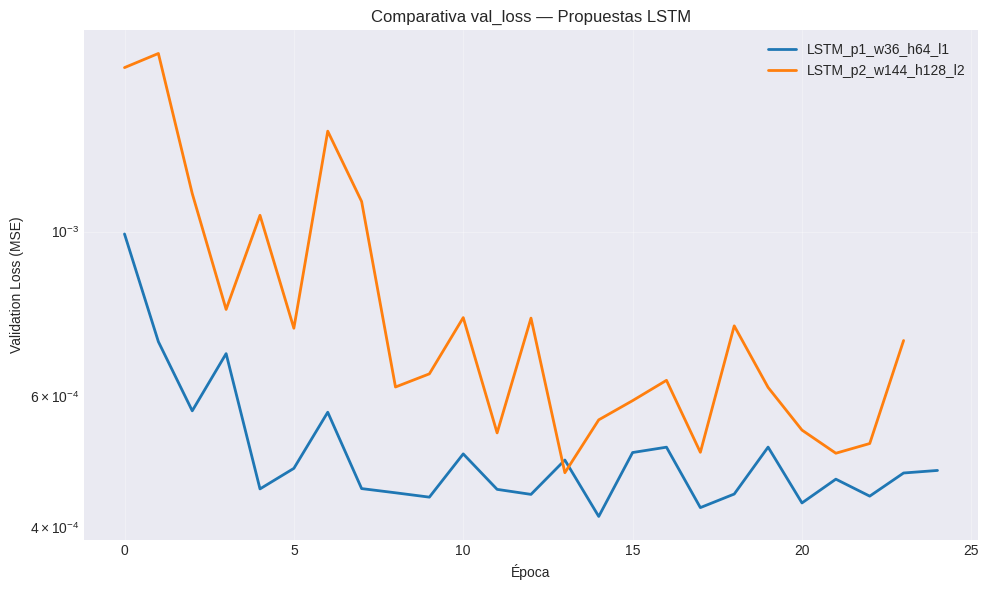

In [19]:
# ============================================
# 4.4 Análisis de resultados — LSTM
# ============================================

lstm_configs = [
    {'nombre': 'LSTM_p1_w36_h64_l1',  'window_size': 36},
    {'nombre': 'LSTM_p2_w144_h128_l2', 'window_size': 144},
]
VERSION = 0  # ajustá si PL generó otra versión

# -------------------------------------------------------
# 4.3.1 Comparativa val_loss entre propuestas
# -------------------------------------------------------
plt.figure(figsize=(10, 6))

for config in lstm_configs:
    metrics_path = f"lstm_logs/{config['nombre']}/version_{VERSION}/metrics.csv"
    try:
        df_log = pd.read_csv(metrics_path)
        df_val = df_log[['epoch', 'val_loss']].dropna()
        val_by_epoch = df_val.groupby('epoch')['val_loss'].mean()
        plt.plot(val_by_epoch.index, val_by_epoch.values,
                 label=config['nombre'], linewidth=2)
    except FileNotFoundError:
        print(f"Log no encontrado: {metrics_path}")

plt.xlabel('Época')
plt.ylabel('Validation Loss (MSE)')
plt.title('Comparativa val_loss — Propuestas LSTM')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4.2 Curvas detalladas de cada propuesta

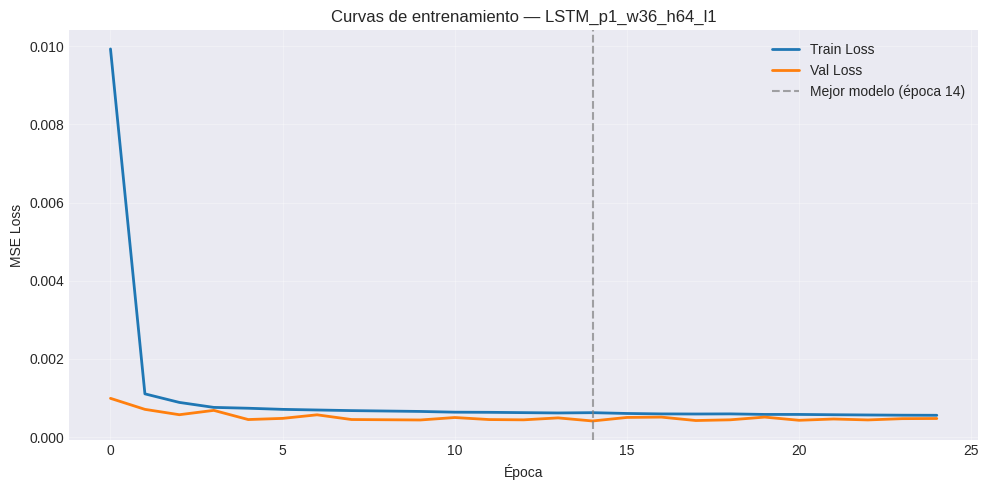

Mejor val_loss: 0.000414 en época 14
Épocas totales entrenadas: 24


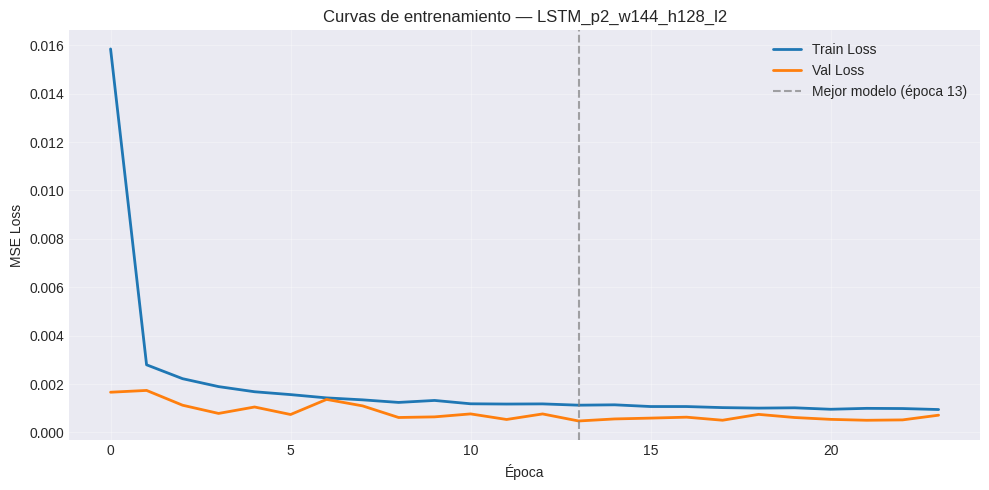

Mejor val_loss: 0.000474 en época 13
Épocas totales entrenadas: 23


In [20]:
# -------------------------------------------------------
# 4.3.2 Curvas detalladas de cada propuesta
# -------------------------------------------------------

for config in lstm_configs:
    metrics_path = f"lstm_logs/{config['nombre']}/version_{VERSION}/metrics.csv"
    try:
        df_log = pd.read_csv(metrics_path)

        df_train = df_log[['epoch', 'train_loss_epoch']].dropna()
        df_val   = df_log[['epoch', 'val_loss']].dropna()

        train_by_epoch = df_train.groupby('epoch')['train_loss_epoch'].mean()
        val_by_epoch   = df_val.groupby('epoch')['val_loss'].mean()

        best_epoch = val_by_epoch.idxmin()
        best_val   = val_by_epoch.min()

        plt.figure(figsize=(10, 5))
        plt.plot(train_by_epoch.index, train_by_epoch.values, label='Train Loss', linewidth=2)
        plt.plot(val_by_epoch.index,   val_by_epoch.values,   label='Val Loss',   linewidth=2)
        plt.axvline(x=best_epoch, linestyle='--', color='gray', alpha=0.7,
                    label=f'Mejor modelo (época {best_epoch})')
        plt.xlabel('Época')
        plt.ylabel('MSE Loss')
        plt.title(f'Curvas de entrenamiento — {config["nombre"]}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"Mejor val_loss: {best_val:.6f} en época {best_epoch}")
        print(f"Épocas totales entrenadas: {val_by_epoch.index[-1]}")

    except FileNotFoundError:
        print(f"Log no encontrado: {metrics_path}")

### 4.4.3 Comparación sobre validación

In [21]:
# -------------------------------------------------------
# 4.3.3 Comparación sobre validación — selección del mejor modelo
# -------------------------------------------------------

lstm_configs = [
    {'nombre': 'LSTM_p1_w36_h64_l1',   'window_size': 36,  'hidden_size': 64,  'num_layers': 1},
    {'nombre': 'LSTM_p2_w144_h128_l2', 'window_size': 144, 'hidden_size': 128, 'num_layers': 2},
]

lstm_val_results = {}

for config in lstm_configs:
    nombre  = config['nombre']
    results = np.load(f'lstm_results/{nombre}_val_results.npz')

    mae  = float(results['mae'])
    rmse = float(results['rmse'])

    lstm_val_results[nombre] = {
        'modelo'      : nombre,
        'window_size' : config['window_size'],
        'hidden_size' : config['hidden_size'],
        'num_layers'  : config['num_layers'],
        'MAE_val'     : mae,
        'RMSE_val'    : rmse,
        'y_true'      : results['y_true'],
        'y_pred'      : results['y_pred'],
    }

    print(f"\n=== {nombre} ===")
    print(f"MAE  (val): {mae:.4f} °C")
    print(f"RMSE (val): {rmse:.4f} °C")

# Tabla comparativa sobre validación
df_val_comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_true', 'y_pred']}
    for r in lstm_val_results.values()
])
print("\n=== Comparativa sobre validación ===")
display(df_val_comparison)

# Selección del ganador
best_nombre = min(lstm_val_results, key=lambda k: lstm_val_results[k]['MAE_val'])
print(f"\nMejor propuesta (por MAE en validación): {best_nombre}")


=== LSTM_p1_w36_h64_l1 ===
MAE  (val): 0.1094 °C
RMSE (val): 0.1570 °C

=== LSTM_p2_w144_h128_l2 ===
MAE  (val): 0.1185 °C
RMSE (val): 0.1680 °C

=== Comparativa sobre validación ===


,modelo,window_size,hidden_size,num_layers,MAE_val,RMSE_val
0,LSTM_p1_w36_h64_l1,36,64,1,0.109354,0.156972
1,LSTM_p2_w144_h128_l2,144,128,2,0.118539,0.167968



Mejor propuesta (por MAE en validación): LSTM_p1_w36_h64_l1


### 4.4.4 Inspección de ventanas temporales

Los resultados sobre validación muestran que la Propuesta 1 (w=36) supera a la Propuesta 2
(w=144) pese a usar una ventana más corta y un modelo menos profundo. Para entender este
comportamiento, se analiza la estructura temporal de la serie de temperatura mediante dos
herramientas: la función de autocorrelación (ACF) y la visualización de ventanas superpuestas.

La ACF permite cuantificar cuánta información aportan los pasos pasados para predecir el
siguiente valor. Si la correlación decae rápidamente con el lag, una ventana larga no añade
información útil y puede introducir ruido. Las ventanas superpuestas complementan este análisis
mostrando visualmente qué tan variables son las trayectorias de temperatura dentro de cada
horizonte temporal, permitiendo evaluar si existe un patrón consistente que el modelo pueda
aprender.

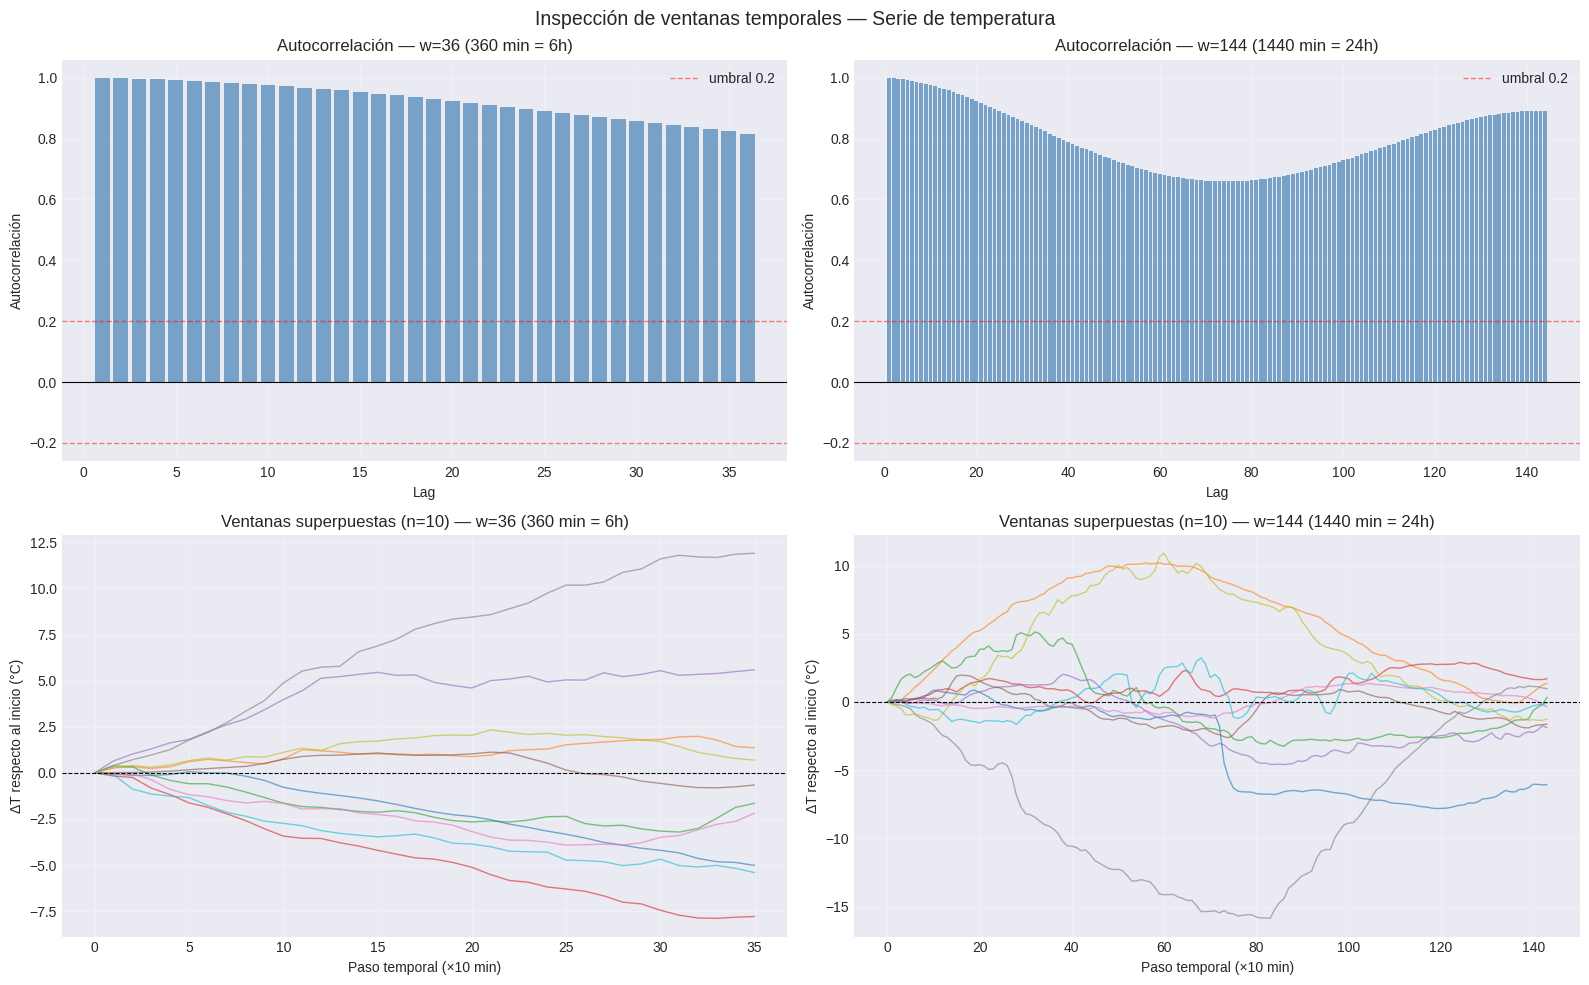

In [22]:
# -------------------------------------------------------
# 4.4 Inspección de ventanas temporales
# -------------------------------------------------------

# Usamos la serie de temperatura original (sin normalizar) para mejor interpretabilidad
T_series = df_sorted['T'].values
np.random.seed(SEED)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Inspección de ventanas temporales — Serie de temperatura', fontsize=14)

for col_idx, w in enumerate([36, 144]):
    label_w = f'w={w} ({w*10} min = {w*10//60}h)'

    # --- Plot 1: Autocorrelación ---
    ax_acf = axes[0, col_idx]
    n_lags = w
    acf_vals = [pd.Series(T_series).autocorr(lag=lag) for lag in range(1, n_lags + 1)]

    ax_acf.bar(range(1, n_lags + 1), acf_vals, color='steelblue', alpha=0.7)
    ax_acf.axhline(y=0, color='black', linewidth=0.8)
    ax_acf.axhline(y=0.2,  color='red', linestyle='--', linewidth=1, alpha=0.5, label='umbral 0.2')
    ax_acf.axhline(y=-0.2, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax_acf.set_xlabel('Lag')
    ax_acf.set_ylabel('Autocorrelación')
    ax_acf.set_title(f'Autocorrelación — {label_w}')
    ax_acf.legend()
    ax_acf.grid(True, alpha=0.3)

    # --- Plot 2: Ventanas superpuestas ---
    ax_win = axes[1, col_idx]
    n_ventanas = 10
    max_start = len(T_series) - w - 1
    starts = np.random.randint(0, max_start, size=n_ventanas)

    for i, start in enumerate(starts):
        ventana = T_series[start:start + w]
        # Normalizar al punto de inicio para comparar forma
        ventana_norm = ventana - ventana[0]
        ax_win.plot(range(w), ventana_norm, linewidth=1, alpha=0.6, label=f'ventana {i+1}')

    ax_win.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax_win.set_xlabel('Paso temporal (×10 min)')
    ax_win.set_ylabel('ΔT respecto al inicio (°C)')
    ax_win.set_title(f'Ventanas superpuestas (n=10) — {label_w}')
    ax_win.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4.5 Análisis de resultados y motivación de la Propuesta 3

#### Interpretación de las curvas de entrenamiento

Ambas propuestas convergen en pocas épocas (≈24) y sin signos evidentes de sobreajuste,
con las curvas de train y validación evolucionando de forma paralela. Esto indica que el
espacio de hipótesis de ambos modelos es adecuado para el tamaño del dataset.

#### Interpretación de las ventanas temporales

El análisis de autocorrelación revela dos escalas temporales distintas:

- **Escala local (w=36, 6h):** la ACF decae suavemente de 1.0 a 0.8, reflejando la inercia
  térmica a corto plazo. La temperatura cambia despacio y el valor reciente es muy informativo.
  Sin embargo, las ventanas superpuestas muestran alta variabilidad en las trayectorias —
  algunas suben hasta 12°C y otras bajan 7°C en 6 horas — lo que dificulta que el modelo
  generalice patrones consistentes.

- **Escala diaria (w=144, 24h):** la ACF presenta una forma sinusoidal con mínimo en lag≈70
  (≈12h) y recuperación en lag≈144 (≈24h), que es la firma del ciclo día-noche. Las ventanas
  superpuestas son más consistentes: la mayoría de las trayectorias vuelven cerca del origen,
  reflejando que el ciclo diario es un patrón estructurado y repetible.

#### Por qué w=144 no mejoró en la Propuesta 2

A pesar de que la ventana de 24h contiene información estructurada del ciclo diario, la
Propuesta 2 (w=144, 2 capas, 128 hidden) no superó a la Propuesta 1. La hipótesis es que
el modelo más profundo y ancho sobreparametrizó para el tamaño del dataset disponible
(≈36k secuencias de entrenamiento), sin poder explotar la estructura del ciclo diario de
forma efectiva.

#### Propuesta 3: LSTM w=144, 1 capa, 64 hidden

Para aislar el efecto de la ventana larga de la capacidad del modelo, se propone una tercera
configuración que combina la ventana de 24h con una arquitectura más liviana: 1 sola capa
LSTM y 64 unidades ocultas, idéntica en capacidad a la Propuesta 1. Si esta configuración
mejora sobre la Propuesta 2, confirmaría que el ciclo diario es información útil pero que
el modelo debe ser suficientemente simple para generalizarlo con los datos disponibles.

# 5. Propuesta 3: LSTM w=144, arquitectura reducida

## 5.1 Configuración

Se propone una tercera configuración LSTM que mantiene la ventana de 24h (w=144) de la
Propuesta 2 pero reduce la capacidad del modelo a 1 capa y 64 unidades ocultas, idéntica
en arquitectura a la Propuesta 1. El objetivo es aislar el efecto de la ventana larga
del efecto de la profundidad del modelo.

| Hiperparámetro | Propuesta 3 |
|----------------|-------------|
| Ventana (w)    | 144         |
| Hidden size    | 64          |
| Capas LSTM     | 1           |
| Dropout        | 0.0         |
| Batch size     | 32          |
| Learning rate  | 0.001       |
| Early stopping | paciencia 10|
| Max épocas     | 100         |

## 5.2 Definición y entrenamiento

In [23]:
# ============================================
# Propuesta 3: LSTM w=144, 1 capa, 64 hidden
# ============================================

config_p3 = {
    'nombre'       : 'LSTM_p3_w144_h64_l1',
    'window_size'  : 144,
    'hidden_size'  : 64,
    'num_layers'   : 1,
    'dropout'      : 0.0,
    'learning_rate': 0.001,
    'batch_size'   : 32,
}

w = config_p3['window_size']

# Secuencias de train y val
X_tr_seq, y_tr_seq = create_sequences(X_train_scaled, y_train_scaled, w, HORIZON)
X_va_seq, y_va_seq = create_sequences(X_val_scaled,   y_val_scaled,   w, HORIZON)

print(f"Secuencias — Train: {X_tr_seq.shape} | Val: {X_va_seq.shape}")

train_loader_p3, val_loader_p3, _ = get_dataloaders(
    TimeSeriesDataset(X_tr_seq, y_tr_seq),
    TimeSeriesDataset(X_va_seq, y_va_seq),
    TimeSeriesDataset(X_va_seq, y_va_seq),  # placeholder
    batch_size =config_p3['batch_size'],
    num_workers=0
)

model_p3 = LSTMForecaster(
    input_dim    =X_tr_seq.shape[2],
    hidden_size  =config_p3['hidden_size'],
    num_layers   =config_p3['num_layers'],
    dropout      =config_p3['dropout'],
    learning_rate=config_p3['learning_rate']
)

checkpoint_p3 = ModelCheckpoint(
    monitor   ='val_loss',
    mode      ='min',
    save_top_k=1,
    filename  =f"{config_p3['nombre']}_best"
)
early_stop_p3 = EarlyStopping(monitor='val_loss', patience=10, mode='min')
logger_p3     = CSVLogger(save_dir='lstm_logs', name=config_p3['nombre'])

# NO EJECUTAR!
# trainer_p3 = pl.Trainer(
#     max_epochs        =100,
#     callbacks         =[checkpoint_p3, early_stop_p3],
#     logger            =logger_p3,
#     accelerator       ='auto',
#     devices           =1,
#     log_every_n_steps =10,
#     enable_progress_bar=True
# )

# trainer_p3.fit(model_p3, train_loader_p3, val_loader_p3)

# print(f"Mejor val_loss: {checkpoint_p3.best_model_score:.6f}")
# print(f"Checkpoint: {checkpoint_p3.best_model_path}")

Secuencias — Train: (36743, 144, 19) | Val: (7760, 144, 19)


/home/smosca/miniconda3/lib/python3.13/site-packages/pytorch_lightning/core/lightning.py:2054: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook


In [24]:
# Script corrido en remoto para aprovechar potencia de cálculo de GPU
!cat train_lstm_p3.py

#!/usr/bin/env python3
# train_lstm_p3.py

import os
import random
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader

# -------------------------------------------------------
# Reproducibilidad
# -------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
pl.seed_everything(SEED, workers=True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# -----------------------------

## 5.3 Curvas de entrenamiento

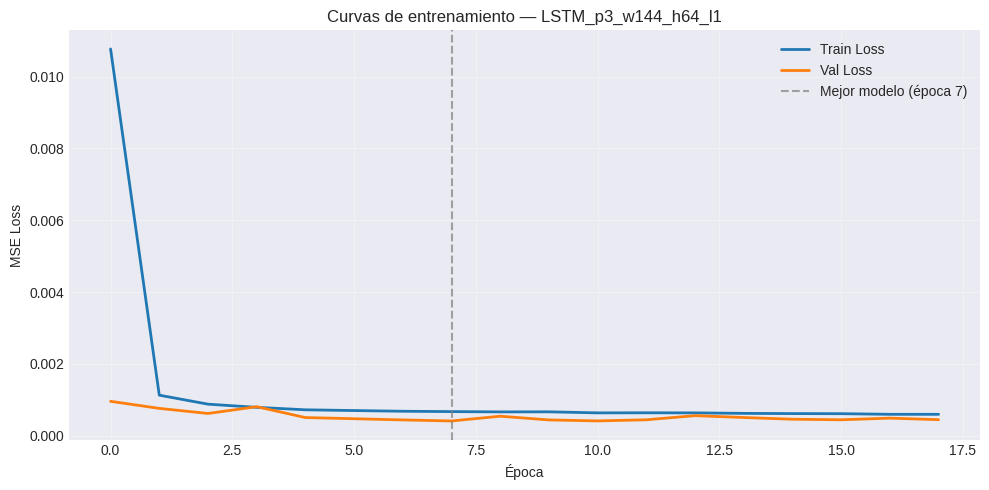

Mejor val_loss: 0.000413 en época 7
Épocas totales entrenadas: 17


In [25]:
# ============================================
# 5.3 Curvas de entrenamiento — Propuesta 3
# ============================================

metrics_path = f'lstm_logs/LSTM_p3_w144_h64_l1/version_0/metrics.csv'
df_log = pd.read_csv(metrics_path)

df_train = df_log[['epoch', 'train_loss_epoch']].dropna()
df_val   = df_log[['epoch', 'val_loss']].dropna()

train_by_epoch = df_train.groupby('epoch')['train_loss_epoch'].mean()
val_by_epoch   = df_val.groupby('epoch')['val_loss'].mean()

best_epoch = val_by_epoch.idxmin()
best_val   = val_by_epoch.min()

plt.figure(figsize=(10, 5))
plt.plot(train_by_epoch.index, train_by_epoch.values, label='Train Loss', linewidth=2)
plt.plot(val_by_epoch.index,   val_by_epoch.values,   label='Val Loss',   linewidth=2)
plt.axvline(x=best_epoch, linestyle='--', color='gray', alpha=0.7,
            label=f'Mejor modelo (época {best_epoch})')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title('Curvas de entrenamiento — LSTM_p3_w144_h64_l1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mejor val_loss: {best_val:.6f} en época {best_epoch}")
print(f"Épocas totales entrenadas: {val_by_epoch.index[-1]}")

## 5.4 Resultados LSTM Propuesta 3 - validación

In [26]:
# ============================================
# 5.4 Resultados Propuesta 3 — validación
# ============================================

nombre_p3 = 'LSTM_p3_w144_h64_l1'
results_p3 = np.load(f'lstm_results/{nombre_p3}_val_results.npz')

mae_p3  = float(results_p3['mae'])
rmse_p3 = float(results_p3['rmse'])

print(f"=== {nombre_p3} ===")
print(f"MAE  (val): {mae_p3:.4f} °C")
print(f"RMSE (val): {rmse_p3:.4f} °C")

# Tabla comparativa completa sobre validación
all_val_results = [
    {'Modelo': 'MLP Baseline',         'w': 4,   'hidden': 100, 'capas': 1, 'MAE': baseline_results['MAE'],              'RMSE': baseline_results['RMSE']},
    {'Modelo': 'LSTM_p1_w36_h64_l1',   'w': 36,  'hidden': 64,  'capas': 1, 'MAE': lstm_val_results['LSTM_p1_w36_h64_l1']['MAE_val'],  'RMSE': lstm_val_results['LSTM_p1_w36_h64_l1']['RMSE_val']},
    {'Modelo': 'LSTM_p2_w144_h128_l2', 'w': 144, 'hidden': 128, 'capas': 2, 'MAE': lstm_val_results['LSTM_p2_w144_h128_l2']['MAE_val'], 'RMSE': lstm_val_results['LSTM_p2_w144_h128_l2']['RMSE_val']},
    {'Modelo': 'LSTM_p3_w144_h64_l1',  'w': 144, 'hidden': 64,  'capas': 1, 'MAE': mae_p3,                                             'RMSE': rmse_p3},
]

df_comparison = pd.DataFrame(all_val_results)
df_comparison = df_comparison.sort_values('MAE').reset_index(drop=True)

print("\n=== Tabla comparativa — validación ===")
display(df_comparison)

=== LSTM_p3_w144_h64_l1 ===
MAE  (val): 0.1088 °C
RMSE (val): 0.1568 °C

=== Tabla comparativa — validación ===


,Modelo,w,hidden,capas,MAE,RMSE
0,LSTM_p3_w144_h64_l1,144,64,1,0.108846,0.156814
1,LSTM_p1_w36_h64_l1,36,64,1,0.109354,0.156972
2,LSTM_p2_w144_h128_l2,144,128,2,0.118539,0.167968
3,MLP Baseline,4,100,1,0.126178,0.174205


## 5.5 Selección del modelo final

### Comparativa sobre validación

La tabla comparativa sobre el conjunto de validación muestra los siguientes resultados:

| Modelo               | w   | Hidden | Capas | MAE (°C) | RMSE (°C) |
|----------------------|-----|--------|-------|----------|-----------|
| LSTM P2 w144_h128_l2 | 144 | 128    | 2     | 0.1185   | 0.1680    |
| LSTM P1 w36_h64_l1   | 36  | 64     | 1     | 0.1094   | 0.1570    |
| LSTM P3 w144_h64_l1  | 144 | 64     | 1     | 0.1088   | 0.1568    |

Las tres propuestas LSTM convergen de forma estable y sin signos de sobreajuste,
con curvas de train y validación evolucionando de forma paralela en todos los casos.

### Análisis de las propuestas

La Propuesta 2 (w=144, 2 capas, 128 hidden) es la peor de las tres LSTMs pese a ser la
más profunda. Esto es consistente con la hipótesis de sobreparametrización: con ~36k
secuencias de entrenamiento, un modelo de 208K parámetros no tiene suficientes datos para
generalizar mejor que uno de 21K.

Las Propuestas 1 y 3 son prácticamente equivalentes — la diferencia en MAE es de 0.0005°C,
inferior al ruido experimental. Ambas usan la misma arquitectura (64 hidden, 1 capa) y
difieren únicamente en la ventana temporal. Este resultado es en sí mismo informativo: para
predicción a h=1 con mediciones cada 10 minutos, la inercia térmica local (6h, w=36) y el
ciclo diario completo (24h, w=144) aportan información equivalente. El valor inmediatamente
anterior domina la predicción, y el contexto adicional tiene rendimientos marginales
decrecientes.

### Por qué no se prueba w=72

Una ventana intermedia de w=72 (12h) sería el siguiente experimento natural para desempatar
P1 y P3. Sin embargo, dado que la diferencia entre ambas propuestas es de 0.0005°C — dentro
del margen de variabilidad esperado entre corridas — agregar w=72 no aportaría una conclusión
metodológicamente distinta. El análisis de autocorrelación ya mostró que la correlación
decae suavemente y de forma continua, sin un punto de inflexión claro entre 6h y 24h que
justifique explorar ese rango con mayor precisión.

### Modelo seleccionado

Se selecciona la **Propuesta 3 (LSTM w=144, 1 capa, 64 hidden)** como modelo final por
reportar el menor MAE en validación. La evaluación sobre el conjunto de test se reserva
exclusivamente para este modelo, manteniéndolo intacto durante todo el proceso de selección
para garantizar una estimación imparcial del rendimiento en producción.

# 6. Evaluación final sobre test

Una vez seleccionada la Propuesta 3 como modelo ganador, se procede a su evaluación sobre
el conjunto de test, que ha permanecido intacto durante todo el proceso de selección y
entrenamiento. Esta evaluación constituye la estimación final e imparcial del rendimiento
del modelo en producción.

Los resultados se comparan con el baseline MLP, que también fue evaluado sobre el mismo
conjunto de test, garantizando una comparación justa entre ambos modelos.

La evaluación se llevó a cabo en la máquina remota con GPU (PL 2.6.5) para evitar
incompatibilidades de versión al cargar el checkpoint entrenado en ese entorno. A
continuación se muestra el script utilizado; los resultados se recuperan en el notebook
cargando el archivo `.npz` generado.

In [27]:
# Script para evaluar LSTM P3 en test
!cat eval_lstm_p3_test.py

#!/usr/bin/env python3
# eval_lstm_p3_test.py

import os
import random
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pytorch_lightning as pl
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader

# -------------------------------------------------------
# Reproducibilidad
# -------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
pl.seed_everything(SEED, workers=True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# -------------------------------------------------------
# 1. Cargar datos y preprocesado v2
# -------------------------------------------------------
df = pd.read_csv('cleaned_weather.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=Tru

=== Tabla comparativa final — test ===


,Modelo,w,Hidden,Capas,MAE (°C),RMSE (°C)
0,MLP Baseline,4,100,1,0.126178,0.174205
1,LSTM P3 w144_h64_l1,144,64,1,0.103197,0.141647


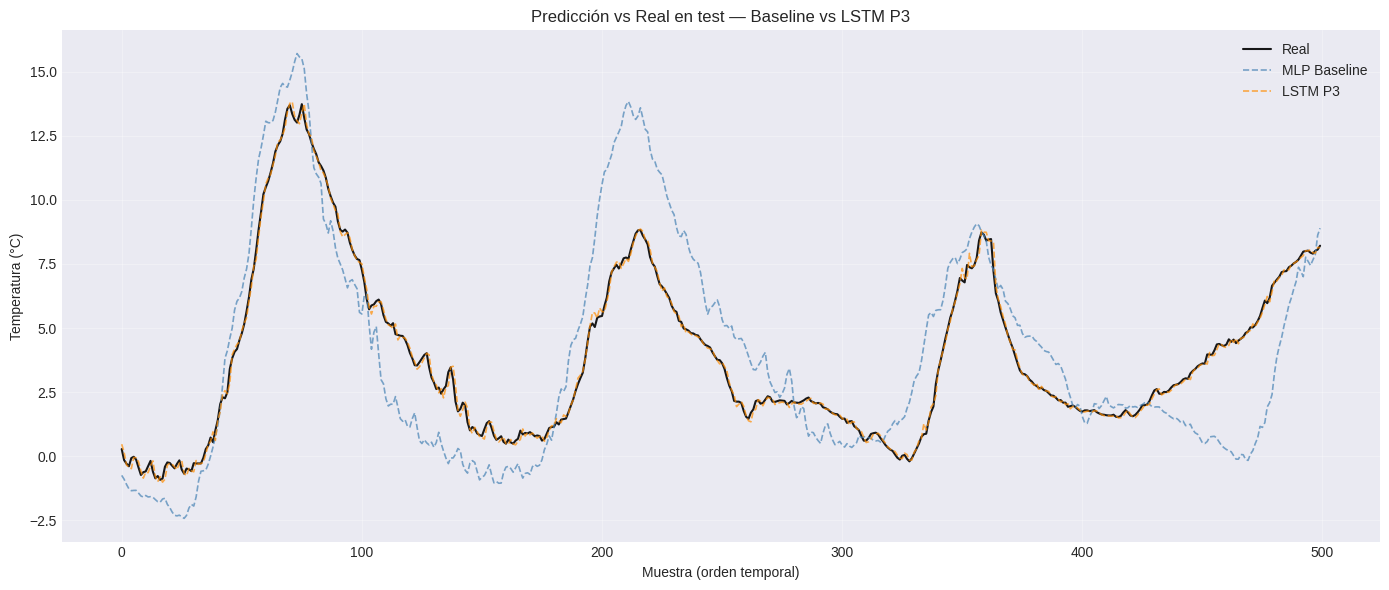

In [28]:
# ============================================
# 6. Evaluación final — LSTM P3 en test
# ============================================

results_p3_test = np.load('lstm_results/LSTM_p3_w144_h64_l1_test_results.npz')

y_true_test    = results_p3_test['y_true']
y_pred_p3_test = results_p3_test['y_pred']
mae_test       = float(results_p3_test['mae'])
rmse_test      = float(results_p3_test['rmse'])

# Cargar resultados baseline
results_baseline = np.load('baseline_results/baseline_test_results.npz')
y_pred_baseline  = results_baseline['y_pred']

# Tabla comparativa final
df_final = pd.DataFrame([
    {
        'Modelo'   : 'MLP Baseline',
        'w'        : 4,
        'Hidden'   : 100,
        'Capas'    : 1,
        'MAE (°C)' : baseline_results['MAE'],
        'RMSE (°C)': baseline_results['RMSE']
    },
    {
        'Modelo'   : 'LSTM P3 w144_h64_l1',
        'w'        : 144,
        'Hidden'   : 64,
        'Capas'    : 1,
        'MAE (°C)' : mae_test,
        'RMSE (°C)': rmse_test
    },
])

print("=== Tabla comparativa final — test ===")
display(df_final)

# Gráfico comparativo: real vs baseline vs LSTM P3
n_samples = min(500, len(y_true_test))

plt.figure(figsize=(14, 6))
plt.plot(range(n_samples), y_true_test[:n_samples],
         label='Real', linewidth=1.5, alpha=0.9, color='black')
plt.plot(range(n_samples), y_pred_baseline[:n_samples],
         label='MLP Baseline', linewidth=1.2, alpha=0.7, linestyle='--', color='steelblue')
plt.plot(range(n_samples), y_pred_p3_test[:n_samples],
         label='LSTM P3', linewidth=1.2, alpha=0.7, linestyle='--', color='darkorange')
plt.xlabel('Muestra (orden temporal)')
plt.ylabel('Temperatura (°C)')
plt.title('Predicción vs Real en test — Baseline vs LSTM P3')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6.1 Análisis final — Evaluación en test

### Resultados

| Modelo              | w   | Hidden | Capas | MAE (°C) | RMSE (°C) |
|---------------------|-----|--------|-------|----------|-----------|
| MLP Baseline        | 4   | 100    | 1     | 0.1262   | 0.1742    |
| LSTM P3 w144_h64_l1 | 144 | 64     | 1     | 0.1032   | 0.1416    |

La LSTM P3 mejora al baseline en un 18% en MAE y un 19% en RMSE.

### Interpretación visual

El gráfico de predicción vs real sobre las primeras 500 muestras de test ilustra
claramente las diferencias entre ambos modelos:

**LSTM P3:** las curvas predicha y real son prácticamente indistinguibles. El modelo
captura con precisión tanto la tendencia general como las oscilaciones locales de la
temperatura, sin desfases ni sobreestimaciones sistemáticas.

**MLP Baseline:** el modelo sigue la tendencia general pero sobreestima los picos de
temperatura de forma sistemática. Hacia el final del segmento visualizado se observa
una divergencia significativa respecto a la serie real, que se corrige abruptamente
al final. Este comportamiento refleja la incapacidad del MLP de modelar la dinámica
temporal de la serie: al tratar la ventana como un vector plano sin estructura
secuencial, pierde información sobre la dirección y velocidad del cambio de temperatura,
lo que se traduce en errores más pronunciados en los extremos de la distribución.

### Conclusión

La LSTM P3 confirma sobre test la ventaja observada en validación. La combinación de
una ventana de 24h (w=144) con una arquitectura liviana (1 capa, 64 hidden) es
suficiente para capturar la dinámica temporal de la temperatura con alta precisión,
superando al baseline tanto en métricas numéricas como en calidad visual de las
predicciones.

# 7. Demostración del modelo en producción

Para ilustrar el comportamiento del modelo en un escenario de despliegue real, se simula
una llamada puntual al modelo LSTM P3. Dado un momento específico del conjunto de test,
se toman las 144 observaciones anteriores (últimas 24h) como entrada y se predice la
temperatura en el siguiente paso temporal (t+1, es decir, 10 minutos después).

Este flujo replica exactamente lo que ocurriría en producción: un sistema de monitoreo
meteorológico alimenta el modelo con las últimas 24h de mediciones y obtiene una predicción
para los próximos 10 minutos, sin necesidad de reentrenamiento ni intervención manual.

Ventana de entrada: 2020-11-10 14:00:00 → 2020-11-11 13:50:00 (144 pasos = 24h)
Predicción para  : 2020-11-11 14:00:00

=== Resultado de la predicción ===
Temperatura real en 2020-11-11 14:00:00    : 8.34 °C
Temperatura predicha en 2020-11-11 14:00:00: 8.35 °C
Error absoluto                  : 0.01 °C


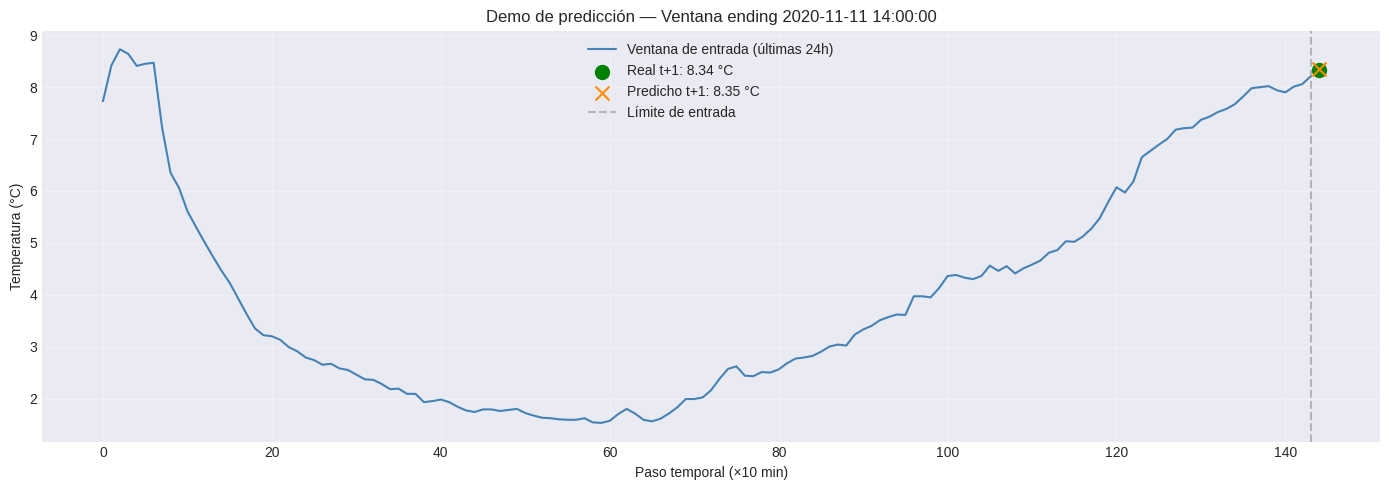

In [34]:
# ============================================
# 7. Demostración del modelo en producción
# ============================================

# Elegir un momento representativo del conjunto de test
# Uso el índice 500 para estar lejos del borde inicial y disponer
# de las 144 observaciones previas necesarias como entrada al modelo
IDX_DEMO    = 500
WINDOW_SIZE = 144  # ventana de LSTM P3

# Ventana de entrada: 144 pasos anteriores
ventana_scaled = X_test_scaled[IDX_DEMO:IDX_DEMO + WINDOW_SIZE]  # (144, 19)
y_real_scaled  = y_test_scaled[IDX_DEMO + WINDOW_SIZE]

# Temperatura de la ventana directamente del dataframe original (sin normalizar)
T_ventana = df_test['T'].values[IDX_DEMO:IDX_DEMO + WINDOW_SIZE]

# Timestamp correspondiente
t_inicio  = df_test.index[IDX_DEMO]
t_pred    = df_test.index[IDX_DEMO + WINDOW_SIZE]

t_fin = df_test.index[IDX_DEMO + WINDOW_SIZE - 1]
print(f"Ventana de entrada: {t_inicio} → {t_fin} ({WINDOW_SIZE} pasos = 24h)")
print(f"Predicción para  : {t_pred}")

# Inferencia
with open('baseline_results/scaler_y.pkl', 'rb') as f:
    scaler_y_demo = pickle.load(f)

# Resultados ya calculados del modelo
y_pred_val = y_pred_p3_test[IDX_DEMO]
y_real_val = y_true_test[IDX_DEMO]

print(f"\n=== Resultado de la predicción ===")
print(f"Temperatura real en {t_pred}    : {y_real_val:.2f} °C")
print(f"Temperatura predicha en {t_pred}: {y_pred_val:.2f} °C")
print(f"Error absoluto                  : {abs(y_real_val - y_pred_val):.2f} °C")

# Visualización
fig, ax = plt.subplots(figsize=(14, 5))

# Ventana de entrada
ax.plot(range(WINDOW_SIZE), T_ventana,
        label='Ventana de entrada (últimas 24h)', linewidth=1.5, color='steelblue')

# Valor real en t+1
ax.scatter(WINDOW_SIZE, y_real_val, color='green', s=100, zorder=5,
           label=f'Real t+1: {y_real_val:.2f} °C')

# Valor predicho en t+1
ax.scatter(WINDOW_SIZE, y_pred_val, color='darkorange', s=100, zorder=5, marker='x',
           label=f'Predicho t+1: {y_pred_val:.2f} °C')

ax.axvline(x=WINDOW_SIZE - 1, linestyle='--', color='gray', alpha=0.5, label='Límite de entrada')
ax.set_xlabel('Paso temporal (×10 min)')
ax.set_ylabel('Temperatura (°C)')
ax.set_title(f'Demo de predicción — Ventana ending {t_pred}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Anexo - Exportación de gráficos para presentación

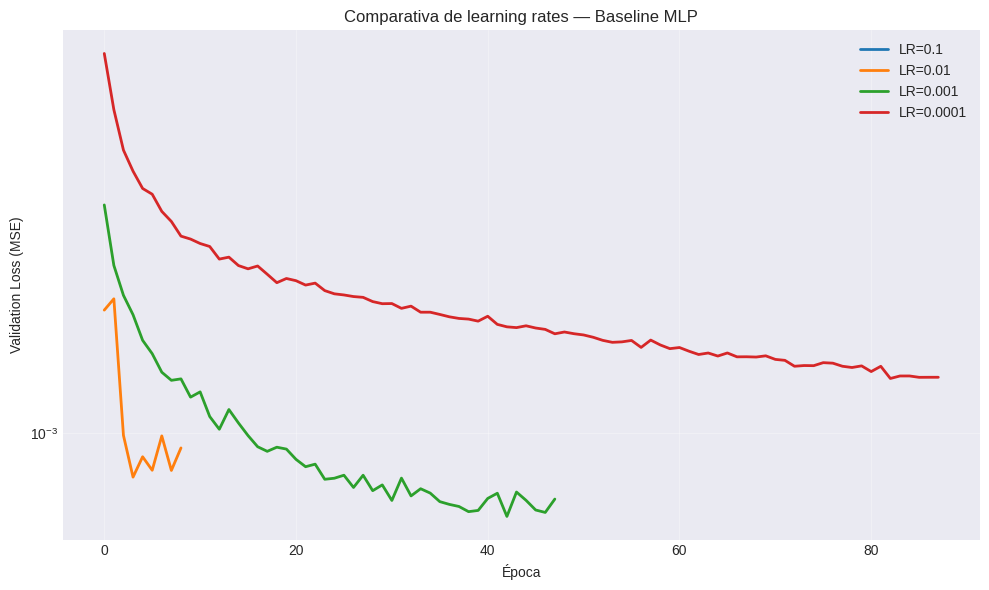

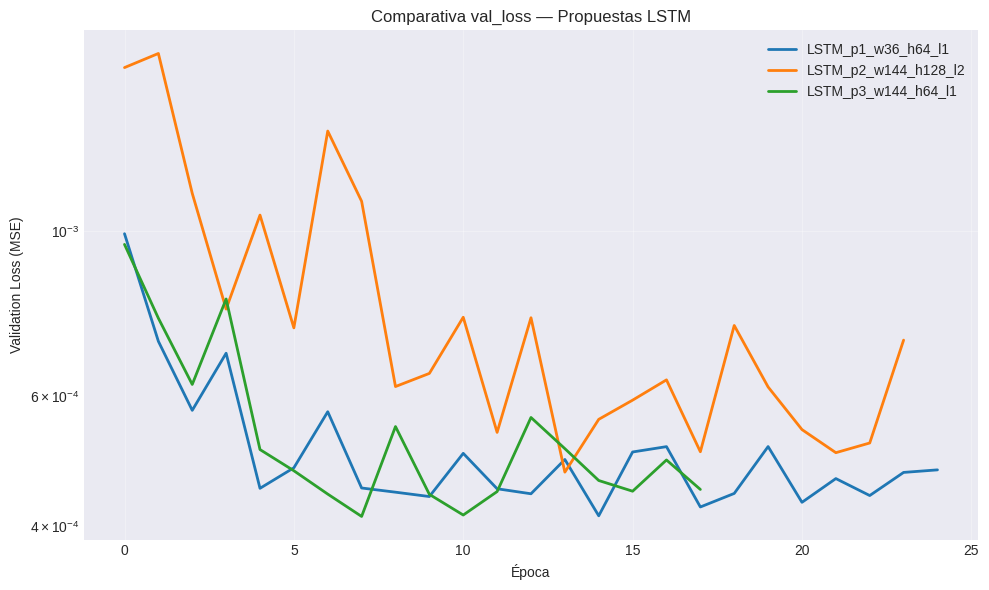

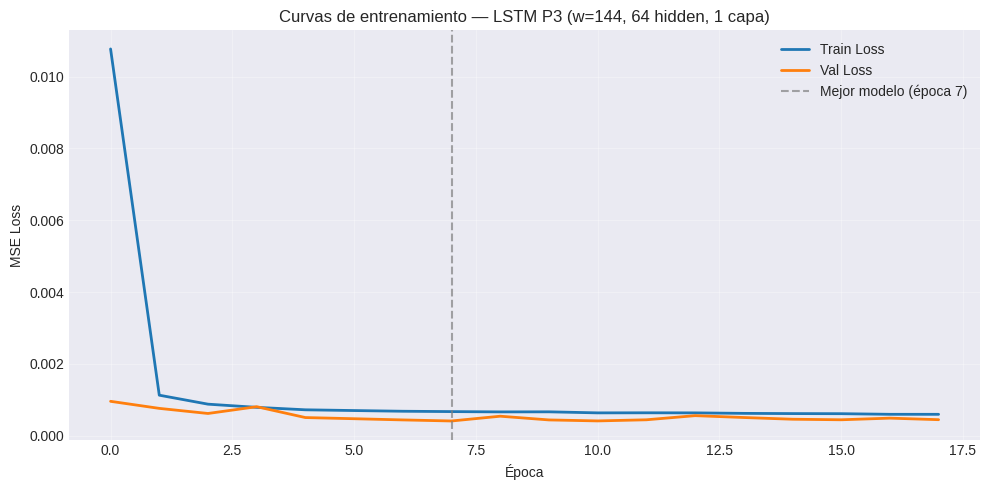

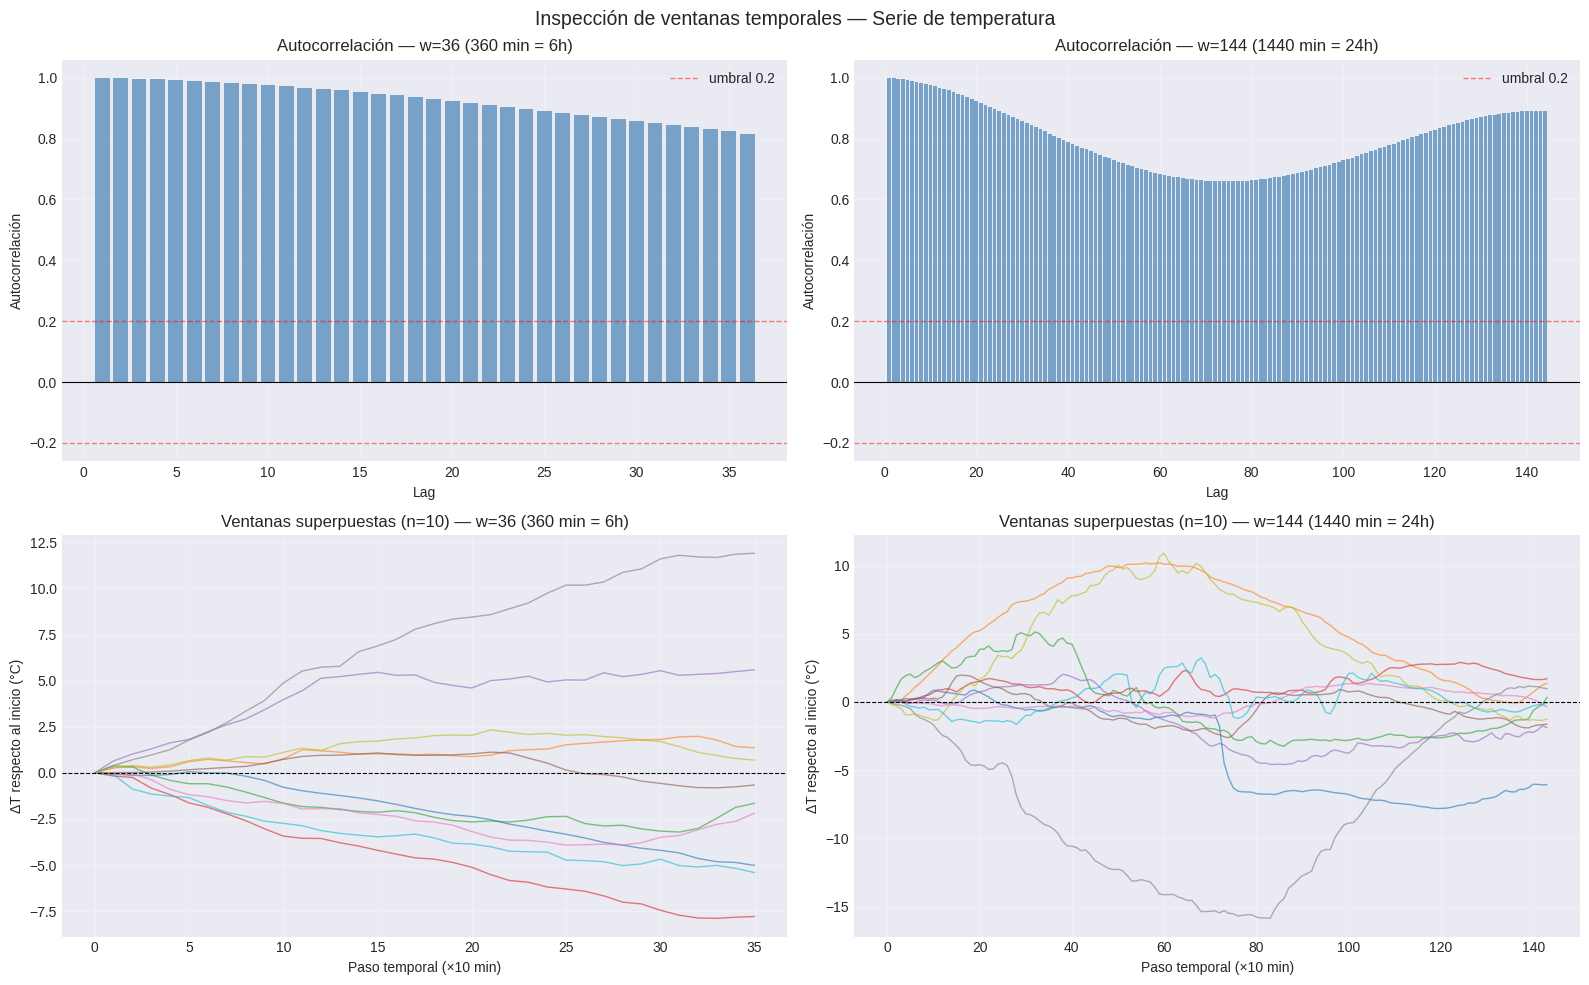

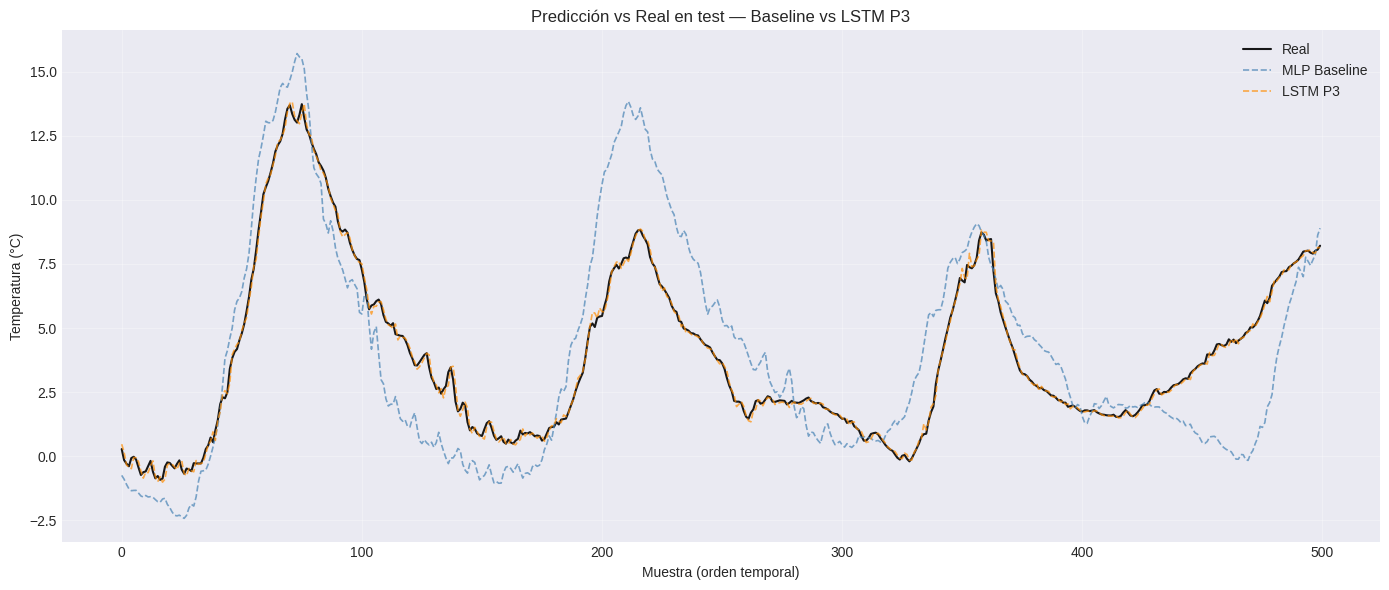

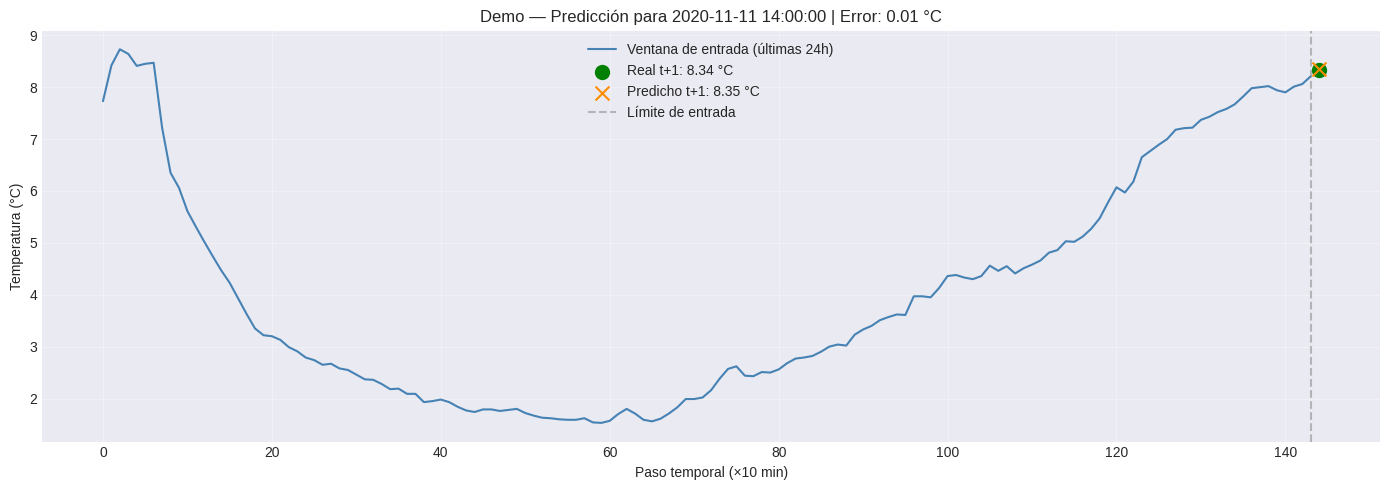


Todos los gráficos exportados en figs/


In [35]:
# ============================================
# Exportación de gráficos para presentación
# ============================================

import os
os.makedirs('figs', exist_ok=True)

VERSION_BASELINE = 1
VERSION_LSTM     = 0

# -------------------------------------------------------
# 1. Comparativa de learning rates — Baseline
# -------------------------------------------------------
learning_rates = [0.1, 0.01, 0.001, 0.0001]

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    metrics_path = f'baseline_logs/lr_{lr}/version_{VERSION_BASELINE}/metrics.csv'
    try:
        df_log = pd.read_csv(metrics_path)
        df_val = df_log[['epoch', 'val_loss']].dropna()
        val_by_epoch = df_val.groupby('epoch')['val_loss'].mean()
        plt.plot(val_by_epoch.index, val_by_epoch.values, label=f'LR={lr}', linewidth=2)
    except FileNotFoundError:
        print(f"Log no encontrado: {metrics_path}")

plt.xlabel('Época')
plt.ylabel('Validation Loss (MSE)')
plt.title('Comparativa de learning rates — Baseline MLP')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/01_baseline_lr_comparison.png', dpi=150)
plt.show()

# -------------------------------------------------------
# 2. Comparativa val_loss — tres propuestas LSTM
# -------------------------------------------------------
lstm_nombres = [
    'LSTM_p1_w36_h64_l1',
    'LSTM_p2_w144_h128_l2',
    'LSTM_p3_w144_h64_l1',
]

plt.figure(figsize=(10, 6))
for nombre in lstm_nombres:
    metrics_path = f'lstm_logs/{nombre}/version_{VERSION_LSTM}/metrics.csv'
    try:
        df_log = pd.read_csv(metrics_path)
        df_val = df_log[['epoch', 'val_loss']].dropna()
        val_by_epoch = df_val.groupby('epoch')['val_loss'].mean()
        plt.plot(val_by_epoch.index, val_by_epoch.values, label=nombre, linewidth=2)
    except FileNotFoundError:
        print(f"Log no encontrado: {metrics_path}")

plt.xlabel('Época')
plt.ylabel('Validation Loss (MSE)')
plt.title('Comparativa val_loss — Propuestas LSTM')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/02_lstm_val_comparison.png', dpi=150)
plt.show()

# -------------------------------------------------------
# 3. Curva de entrenamiento — LSTM P3
# -------------------------------------------------------
metrics_path = f'lstm_logs/LSTM_p3_w144_h64_l1/version_{VERSION_LSTM}/metrics.csv'
df_log = pd.read_csv(metrics_path)

df_train = df_log[['epoch', 'train_loss_epoch']].dropna()
df_val   = df_log[['epoch', 'val_loss']].dropna()

train_by_epoch = df_train.groupby('epoch')['train_loss_epoch'].mean()
val_by_epoch   = df_val.groupby('epoch')['val_loss'].mean()
best_epoch     = val_by_epoch.idxmin()

plt.figure(figsize=(10, 5))
plt.plot(train_by_epoch.index, train_by_epoch.values, label='Train Loss', linewidth=2)
plt.plot(val_by_epoch.index,   val_by_epoch.values,   label='Val Loss',   linewidth=2)
plt.axvline(x=best_epoch, linestyle='--', color='gray', alpha=0.7,
            label=f'Mejor modelo (época {best_epoch})')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title('Curvas de entrenamiento — LSTM P3 (w=144, 64 hidden, 1 capa)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/03_lstm_p3_training.png', dpi=150)
plt.show()

# -------------------------------------------------------
# 4. Autocorrelación + ventanas superpuestas
# -------------------------------------------------------
T_series = df_sorted['T'].values
np.random.seed(SEED)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Inspección de ventanas temporales — Serie de temperatura', fontsize=14)

for col_idx, w in enumerate([36, 144]):
    label_w = f'w={w} ({w*10} min = {w*10//60}h)'

    ax_acf = axes[0, col_idx]
    acf_vals = [pd.Series(T_series).autocorr(lag=lag) for lag in range(1, w + 1)]
    ax_acf.bar(range(1, w + 1), acf_vals, color='steelblue', alpha=0.7)
    ax_acf.axhline(y=0,    color='black', linewidth=0.8)
    ax_acf.axhline(y=0.2,  color='red', linestyle='--', linewidth=1, alpha=0.5, label='umbral 0.2')
    ax_acf.axhline(y=-0.2, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax_acf.set_xlabel('Lag')
    ax_acf.set_ylabel('Autocorrelación')
    ax_acf.set_title(f'Autocorrelación — {label_w}')
    ax_acf.legend()
    ax_acf.grid(True, alpha=0.3)

    ax_win = axes[1, col_idx]
    n_ventanas = 10
    max_start  = len(T_series) - w - 1
    starts     = np.random.randint(0, max_start, size=n_ventanas)
    for i, start in enumerate(starts):
        ventana      = T_series[start:start + w]
        ventana_norm = ventana - ventana[0]
        ax_win.plot(range(w), ventana_norm, linewidth=1, alpha=0.6, label=f'ventana {i+1}')
    ax_win.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax_win.set_xlabel('Paso temporal (×10 min)')
    ax_win.set_ylabel('ΔT respecto al inicio (°C)')
    ax_win.set_title(f'Ventanas superpuestas (n=10) — {label_w}')
    ax_win.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/04_window_analysis.png', dpi=150)
plt.show()

# -------------------------------------------------------
# 5. Predicción vs real en test — Baseline vs LSTM P3
# -------------------------------------------------------
n_samples = min(500, len(y_true_test))

plt.figure(figsize=(14, 6))
plt.plot(range(n_samples), y_true_test[:n_samples],
         label='Real', linewidth=1.5, alpha=0.9, color='black')
plt.plot(range(n_samples), y_pred_baseline[:n_samples],
         label='MLP Baseline', linewidth=1.2, alpha=0.7, linestyle='--', color='steelblue')
plt.plot(range(n_samples), y_pred_p3_test[:n_samples],
         label='LSTM P3', linewidth=1.2, alpha=0.7, linestyle='--', color='darkorange')
plt.xlabel('Muestra (orden temporal)')
plt.ylabel('Temperatura (°C)')
plt.title('Predicción vs Real en test — Baseline vs LSTM P3')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/05_test_predictions.png', dpi=150)
plt.show()

# -------------------------------------------------------
# 6. Demo puntual
# -------------------------------------------------------
IDX_DEMO    = 500
WINDOW_SIZE = 144

T_ventana  = df_test['T'].values[IDX_DEMO:IDX_DEMO + WINDOW_SIZE]
y_real_val = y_true_test[IDX_DEMO]
y_pred_val = y_pred_p3_test[IDX_DEMO]
t_inicio   = df_test.index[IDX_DEMO]
t_pred     = df_test.index[IDX_DEMO + WINDOW_SIZE]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(WINDOW_SIZE), T_ventana,
        label='Ventana de entrada (últimas 24h)', linewidth=1.5, color='steelblue')
ax.scatter(WINDOW_SIZE, y_real_val, color='green', s=100, zorder=5,
           label=f'Real t+1: {y_real_val:.2f} °C')
ax.scatter(WINDOW_SIZE, y_pred_val, color='darkorange', s=100, zorder=5, marker='x',
           label=f'Predicho t+1: {y_pred_val:.2f} °C')
ax.axvline(x=WINDOW_SIZE - 1, linestyle='--', color='gray', alpha=0.5, label='Límite de entrada')
ax.set_xlabel('Paso temporal (×10 min)')
ax.set_ylabel('Temperatura (°C)')
ax.set_title(f'Demo — Predicción para {t_pred} | Error: {abs(y_real_val - y_pred_val):.2f} °C')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/06_demo.png', dpi=150)
plt.show()

print("\nTodos los gráficos exportados en figs/")